# Proyecto: Clasificador de Letras ASL

Seleccionamos una submuestra del dataset original de Kaggle para este laboratorio. Tomamos 600 imágenes por cada clase, suficiente para capturar la variabilidad de los datos sin sobrepasar las limitaciones de cómputo y tiempo del entorno de trabajo.

## Ejemplos de imágenes

Mostramos ejemplos de cinco letras distintas del alfabeto ASL para observar la variabilidad de las imágenes dentro de una misma clase.

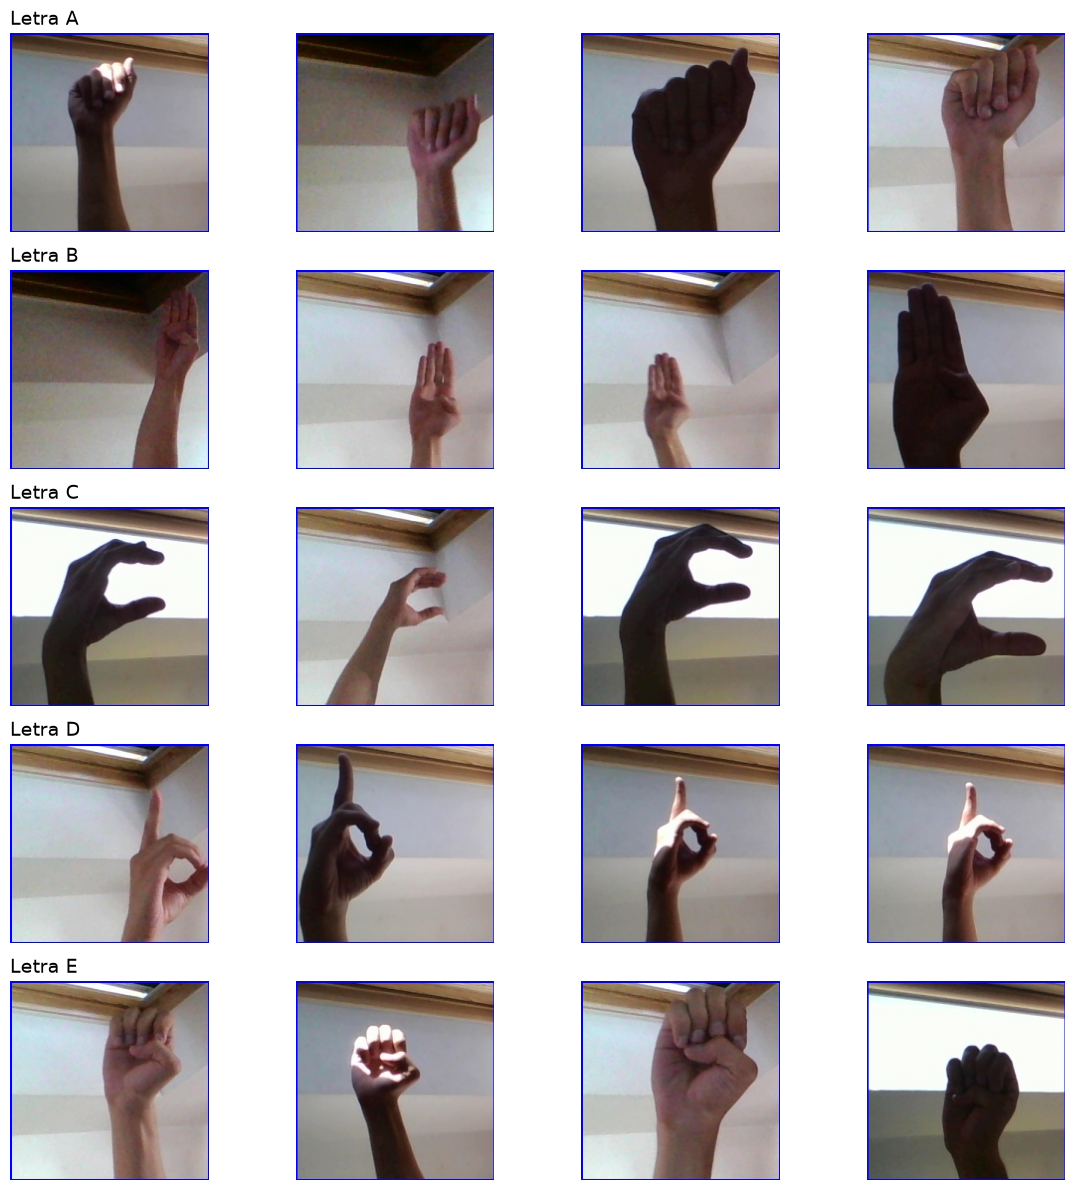

In [3]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

letras = ['A', 'B', 'C', 'D', 'E']
muestras_por_letra = 4
base_path = '../data'

fig, axes = plt.subplots(len(letras), muestras_por_letra, figsize=(12, 12))

for i, letra in enumerate(letras):
    letra_path = os.path.join(base_path, letra)
    if os.path.exists(letra_path):
        imagenes = os.listdir(letra_path)[:muestras_por_letra]
        for j, img_name in enumerate(imagenes):
            img_path = os.path.join(letra_path, img_name)
            img = mpimg.imread(img_path)
            ax = axes[i, j]
            ax.imshow(img)
            ax.axis('off')
            if j == 0:
                ax.set_title(f'Letra {letra}', fontsize=14, loc='left')

plt.tight_layout()
plt.show()

Dentro de cada letra hay cambios importantes en la iluminación y el tipo de fondo. También hay variaciones en la posición y el ángulo de la mano, y en la distancia de la mano a la cámara.

## Análisis exploratorio

In [4]:
from PIL import Image
import os

base_path = '../data'
clases = sorted(os.listdir(base_path))

tamaños = set()
formatos = set()
modos = set()

for clase in clases:
    clase_path = os.path.join(base_path, clase)
    for nombre_img in os.listdir(clase_path)[:5]:
        img = Image.open(os.path.join(clase_path, nombre_img))
        tamaños.add(img.size)
        formatos.add(img.format)
        modos.add(img.mode)

print('Dimensiones encontradas:', tamaños)
print('Formatos encontrados:', formatos)
print('Modos de color encontrados:', modos)

Dimensiones encontradas: {(200, 200)}
Formatos encontrados: {'JPEG'}
Modos de color encontrados: {'RGB'}


Revisamos una muestra de imágenes de cada una de las 29 clases y todas tienen la misma resolución de 200x200 píxeles, están en formato JPEG y son a color con los tres canales RGB. No hay imágenes en escala de grises ni con dimensiones distintas dentro de la submuestra.

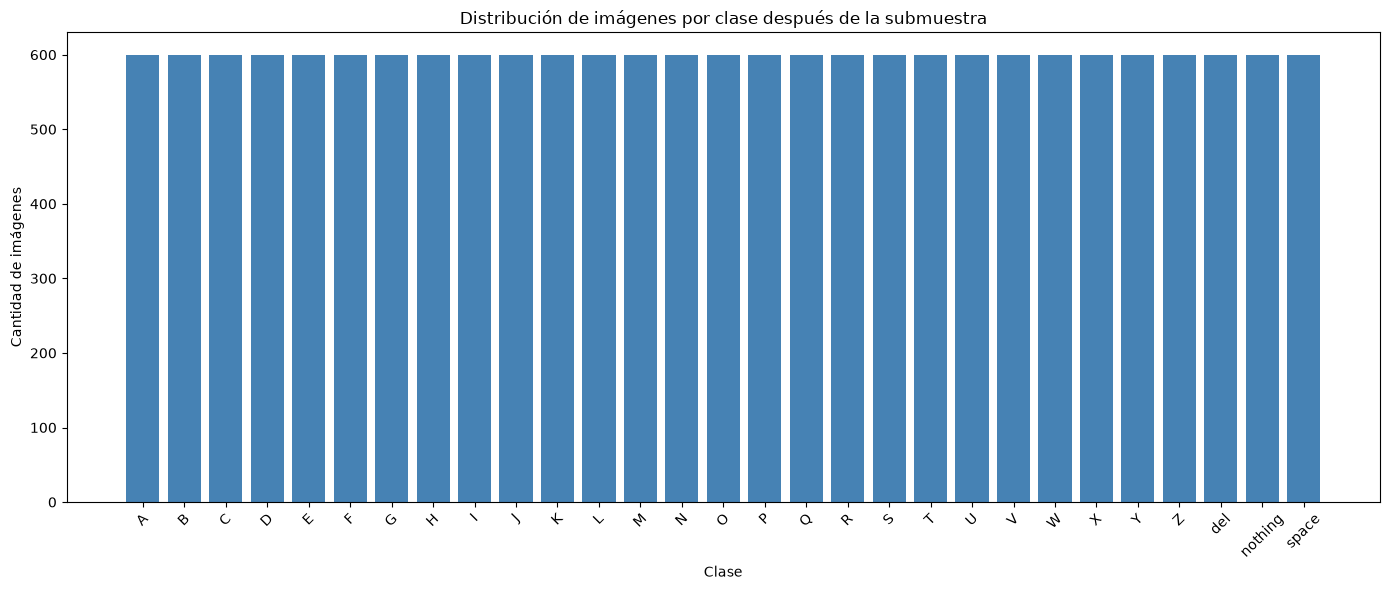

Mínimo de imágenes en una clase: 600
Máximo de imágenes en una clase: 600


In [5]:
conteo_clases = {clase: len(os.listdir(os.path.join(base_path, clase))) for clase in clases}

plt.figure(figsize=(14, 6))
plt.bar(conteo_clases.keys(), conteo_clases.values(), color='steelblue')
plt.xlabel('Clase')
plt.ylabel('Cantidad de imágenes')
plt.title('Distribución de imágenes por clase después de la submuestra')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Mínimo de imágenes en una clase:', min(conteo_clases.values()))
print('Máximo de imágenes en una clase:', max(conteo_clases.values()))

Las 29 clases quedaron con exactamente 600 imágenes cada una, el mínimo y el máximo por clase coinciden. El dataset original tenía suficientes imágenes disponibles por letra y la submuestra queda perfectamente balanceada.

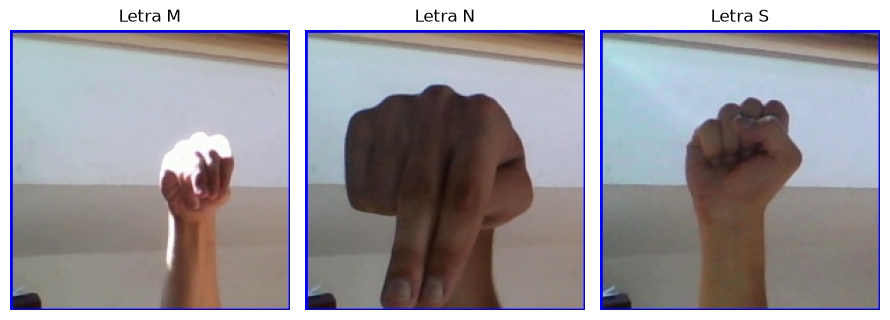

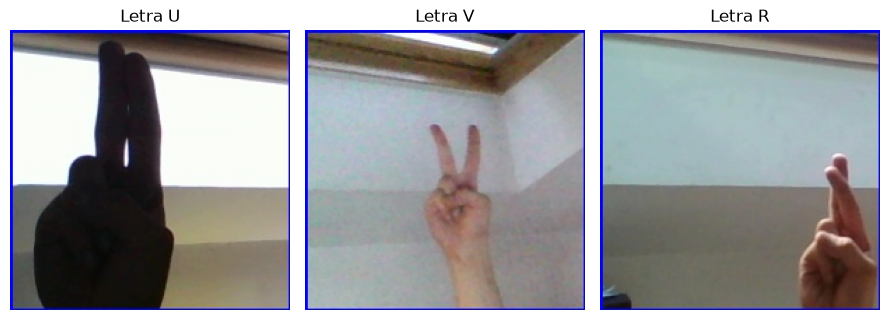

In [6]:
grupos_similares = [['M', 'N', 'S'], ['U', 'V', 'R']]

for grupo in grupos_similares:
    fig, axes = plt.subplots(1, len(grupo), figsize=(9, 4))
    for ax, letra in zip(axes, grupo):
        letra_path = os.path.join(base_path, letra)
        img_name = os.listdir(letra_path)[0]
        img = mpimg.imread(os.path.join(letra_path, img_name))
        ax.imshow(img)
        ax.set_title(f'Letra {letra}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

Las letras M, N y S se parecen porque las tres se forman con el puño cerrado y el pulgar escondido debajo de los otros dedos, la diferencia entre ellas es solo la posición exacta del pulgar respecto a los dedos que lo cubren. Algo similar pasa con U, V y R, que se hacen con dos dedos extendidos y varían únicamente en si están juntos, separados o cruzados.

Para el modelo esto puede ser un problema porque son diferencias muy pequeñas en la imagen, casi a nivel de píxeles, y se pueden perder fácilmente con variaciones de ángulo, iluminación o resolución. Es probable que estas letras generen más confusión en la clasificación que otras con formas de mano claramente distintas.

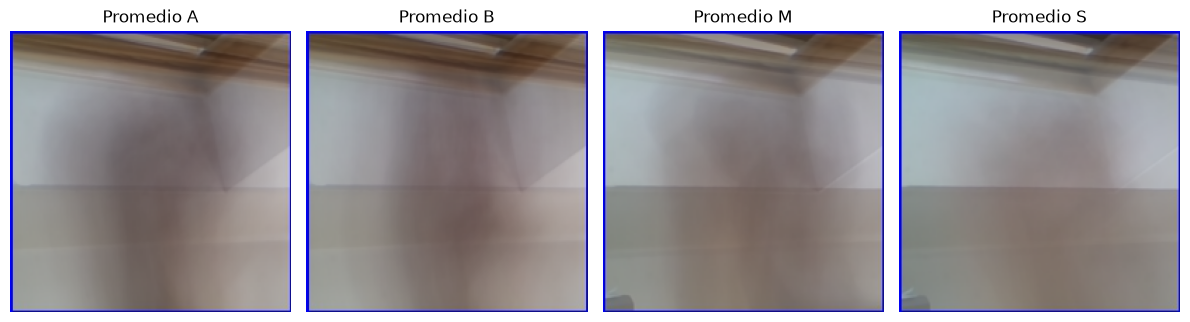

In [7]:
import numpy as np

clases_promedio = ['A', 'B', 'M', 'S']

fig, axes = plt.subplots(1, len(clases_promedio), figsize=(12, 4))

for ax, clase in zip(axes, clases_promedio):
    clase_path = os.path.join(base_path, clase)
    imagenes = os.listdir(clase_path)
    acumulador = np.zeros((200, 200, 3), dtype=np.float64)
    for nombre_img in imagenes:
        img = np.array(Image.open(os.path.join(clase_path, nombre_img)))
        acumulador += img
    promedio = (acumulador / len(imagenes)).astype(np.uint8)
    ax.imshow(promedio)
    ax.set_title(f'Promedio {clase}')
    ax.axis('off')

plt.tight_layout()
plt.show()

La imagen promedio se construye sumando pixel por pixel todas las fotos de una clase y dividiendo entre el total de imágenes. Si la seña se hace siempre en una posición y encuadre parecidos, el promedio sale nítido, con la forma de la mano reconocible. Si hay mucha variación de posición dentro de la clase, el promedio se ve borroso porque los bordes de la mano caen en lugares distintos de cada foto.

En las cuatro clases pasó lo segundo. El fondo, la pared y el borde de la puerta se ven casi idénticos entre A, B, M y S, lo que indica que las fotos se tomaron con la cámara fija en la misma posición. La mano en sí se pierde en una mancha difusa color piel en el centro de la imagen, sin bordes definidos, y esto pasa igual de fuerte en las cuatro letras, no solo en el grupo M y S que ya marcamos como confuso. Promediar pixeles crudos no sirve para distinguir señas, porque la posición de la mano varía lo suficiente dentro de cada clase como para que el promedio no conserve la forma. El modelo va a necesitar aprender patrones espaciales locales en vez de depender de estadísticas simples de pixel.

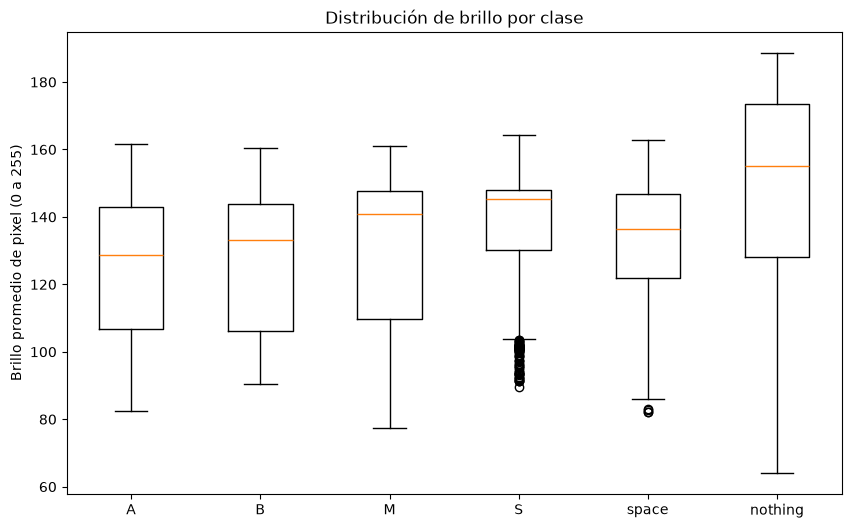

A: media=126.2, desviación=20.4
B: media=127.6, desviación=20.6
M: media=130.8, desviación=20.4
S: media=136.8, desviación=18.3
space: media=131.8, desviación=18.4
nothing: media=146.9, desviación=29.5


In [8]:
clases_brillo = ['A', 'B', 'M', 'S', 'space', 'nothing']
brillo_por_clase = {}

for clase in clases_brillo:
    clase_path = os.path.join(base_path, clase)
    valores = [np.array(Image.open(os.path.join(clase_path, nombre_img))).mean()
               for nombre_img in os.listdir(clase_path)]
    brillo_por_clase[clase] = valores

plt.figure(figsize=(10, 6))
plt.boxplot(brillo_por_clase.values(), tick_labels=brillo_por_clase.keys())
plt.ylabel('Brillo promedio de pixel (0 a 255)')
plt.title('Distribución de brillo por clase')
plt.show()

for clase, valores in brillo_por_clase.items():
    valores = np.array(valores)
    print(f'{clase}: media={valores.mean():.1f}, desviación={valores.std():.1f}')

Tomamos el brillo promedio de pixel de cada imagen como métrica simple y comparamos su distribución entre seis clases: cuatro letras (A, B, M, S) más las clases especiales space y nothing, que no corresponden a una letra sino a espacio y ausencia de seña.

A, B, M, S y space quedan en rangos de brillo muy parecidos entre sí, con medias entre 126.2 y 136.8 y desviaciones de 18.3 a 20.6. La clase nothing es la que se distingue: su media sube a 146.9 y su desviación llega a 29.5. Tiene sentido, porque nothing captura escenas sin mano en el encuadre, así que queda más expuesta a cambios de iluminación de fondo y menos cubierta por la sombra que genera la propia mano cuando está presente. Para las letras entre sí el brillo no aporta mucho, porque la iluminación depende más de la sesión de captura que de la seña específica.

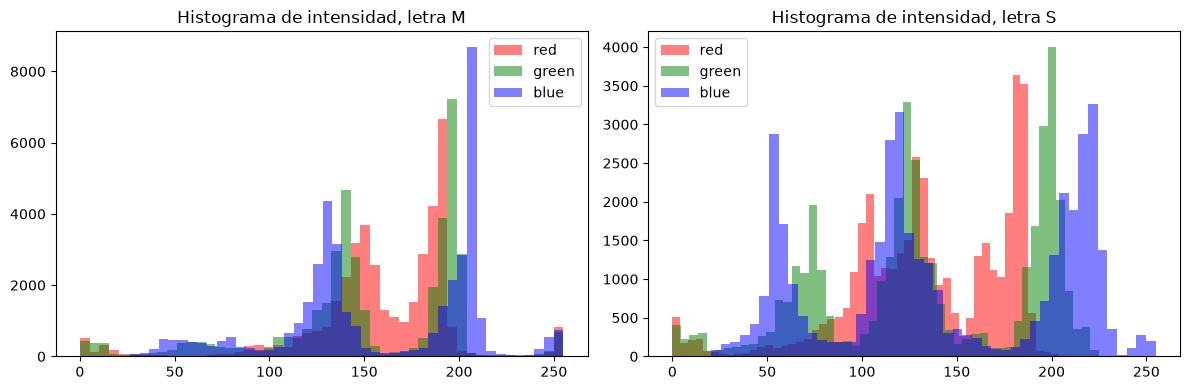

In [9]:
clases_hist = ['M', 'S']

fig, axes = plt.subplots(1, len(clases_hist), figsize=(12, 4))

for ax, clase in zip(axes, clases_hist):
    clase_path = os.path.join(base_path, clase)
    img_name = os.listdir(clase_path)[0]
    img = np.array(Image.open(os.path.join(clase_path, img_name)))
    for canal, color in enumerate(['red', 'green', 'blue']):
        ax.hist(img[:, :, canal].ravel(), bins=50, color=color, alpha=0.5, label=color)
    ax.set_title(f'Histograma de intensidad, letra {clase}')
    ax.legend()

plt.tight_layout()
plt.show()

Tomamos una imagen representativa de M y otra de S y graficamos la intensidad de cada canal de color por separado. En ambas letras los tres canales, rojo, verde y azul, siguen prácticamente la misma forma de distribución, solo desplazados un poco entre sí, lo cual es normal en piel bajo luz interior. No hay un canal que se dispare independiente de los otros.

Esto importa para la decisión de color contra escala de grises que documentamos más adelante en preprocesamiento, porque si los tres canales se mueven juntos, convertir a escala de grises no debería perder información relevante para distinguir la forma de la mano. La distribución en sí varía de imagen a imagen según el fondo y la sombra de esa foto puntual, como se ve en que M tiene un pico más marcado cerca de 200 y S tiene la masa más repartida entre valores bajos y altos, pero eso depende de la escena capturada en esa imagen particular, no de un patrón sistemático de la letra.

### Split de entrenamiento, validación y prueba

El set de prueba que trae Kaggle para este dataset viene con muy pocas imágenes, pensado más para una demo que para evaluar un modelo con seriedad. Por eso armamos nuestro propio split a partir de los datos de entrenamiento que ya tenemos descargados, en vez de depender de ese set oficial.

Usamos una proporción 70 por ciento entrenamiento, 15 por ciento validación y 15 por ciento prueba, estratificada por clase para que las 29 letras mantengan la misma proporción en los tres conjuntos. Estratificar es importante acá porque aunque el dataset está balanceado en total, un split aleatorio simple podría dejar alguna clase con pocas imágenes en validación o prueba solo por azar, y eso haría más ruidosa la evaluación de esa clase en particular. Con 600 imágenes por clase, un 15 por ciento son 90 imágenes de prueba por letra, suficiente para medir el desempeño sin sacrificar demasiados datos de entrenamiento.

In [10]:
from sklearn.model_selection import train_test_split

archivos = []
etiquetas = []

for clase in clases:
    clase_path = os.path.join(base_path, clase)
    for nombre_img in os.listdir(clase_path):
        archivos.append(os.path.join(clase_path, nombre_img))
        etiquetas.append(clase)

archivos_train, archivos_temp, etiquetas_train, etiquetas_temp = train_test_split(
    archivos, etiquetas, test_size=0.30, stratify=etiquetas, random_state=42
)

archivos_val, archivos_test, etiquetas_val, etiquetas_test = train_test_split(
    archivos_temp, etiquetas_temp, test_size=0.50, stratify=etiquetas_temp, random_state=42
)

print('Entrenamiento:', len(archivos_train))
print('Validación:', len(archivos_val))
print('Prueba:', len(archivos_test))
print('Ejemplo de imágenes de prueba para la clase A:', etiquetas_test.count('A'))

Entrenamiento: 12180
Validación: 2610
Prueba: 2610
Ejemplo de imágenes de prueba para la clase A: 90


Con las 17400 imágenes de la submuestra, el split queda en 12180 para entrenamiento, 2610 para validación y 2610 para prueba, y la clase A aporta exactamente 90 imágenes al set de prueba, igual que cada una de las 29 clases. Guardamos las listas de rutas de archivo y etiquetas de cada conjunto para usarlas directamente en el pipeline de entrenamiento.

## Preprocesamiento

Antes de entrenar cualquier modelo hay que dejar las 17400 imágenes en un formato manejable para el hardware disponible en el laboratorio. Las imágenes originales vienen a 200x200 en RGB, lo que da 40000 pixeles por canal y 120000 valores por imagen. Entrenar varias arquitecturas distintas sobre eso, incluyendo un Random Forest que no tiene forma de compartir cómputo entre pixeles como sí lo hace una convolución, sale caro en tiempo.

Por eso reducimos cada imagen a 64x64 antes de meterla a cualquier modelo. Esto deja 4096 pixeles por canal, casi 10 veces menos que el original, y sigue siendo suficiente resolución para que se distinga la forma general de la mano y la posición de los dedos, que es la información que separa una letra de otra. El detalle fino que se pierde al reducir, como la textura de la piel o pequeñas variaciones de sombra, no aporta a la tarea de clasificación y hasta podría hacer que el modelo se sobreajuste a detalles irrelevantes de cada foto.

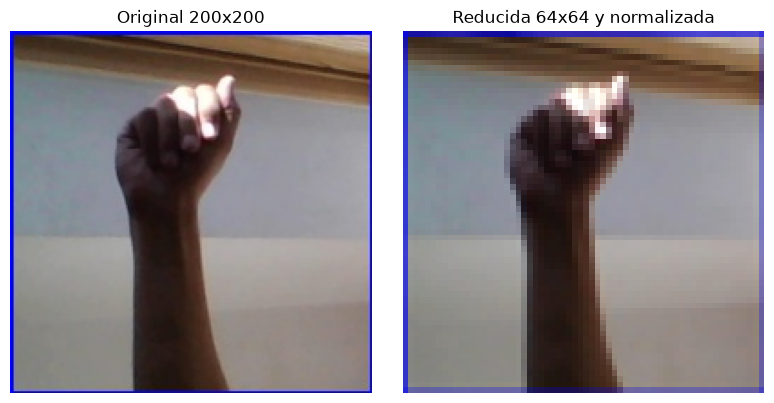

Rango de valores original: 0 a 255
Rango de valores normalizado: 0.027 a 1.0


In [11]:
TAMANO_DESTINO = (64, 64)

clase_ejemplo = 'A'
clase_ejemplo_path = os.path.join(base_path, clase_ejemplo)
img_path = os.path.join(clase_ejemplo_path, os.listdir(clase_ejemplo_path)[0])

img_original = Image.open(img_path)
img_original_array = np.array(img_original)

img_reducida = img_original.resize(TAMANO_DESTINO)
img_normalizada = np.array(img_reducida) / 255.0

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_original_array)
axes[0].set_title(f'Original {img_original.size[0]}x{img_original.size[1]}')
axes[0].axis('off')
axes[1].imshow(img_normalizada)
axes[1].set_title(f'Reducida {TAMANO_DESTINO[0]}x{TAMANO_DESTINO[1]} y normalizada')
axes[1].axis('off')
plt.tight_layout()
plt.show()

print('Rango de valores original:', img_original_array.min(), 'a', img_original_array.max())
print('Rango de valores normalizado:', round(img_normalizada.min(), 3), 'a', round(img_normalizada.max(), 3))

Para la normalización dividimos cada pixel entre 255 para dejarlo en el rango de 0 a 1, en vez de estandarizar restando la media y dividiendo entre la desviación estándar. En la imagen de ejemplo el rango pasa de 0 a 255 a quedar entre 0.027 y 1.0. Con ese rango alcanza para este caso porque las imágenes ya vienen en una escala de iluminación bastante uniforme, según la distribución de brillo por clase, así que no hace falta el paso extra de calcular media y desviación por canal sobre todo el set de entrenamiento.

Mantenemos las imágenes a color en vez de pasarlas a escala de grises. Un solo canal ahorraría memoria, pero en el histograma de intensidad de M y S los tres canales se mueven prácticamente juntos, lo que confirma que no hay señal de color que separe las letras entre sí, la información está en la forma de la mano y no en el tono. Dejamos los tres canales porque el costo de cómputo ya se resolvió con la reducción a 64x64, y quitar canales en este punto sería una optimización que no hace falta para el tamaño de este laboratorio.

No aplicamos ningún filtro adicional de suavizado o realce de bordes. Las fotos ya vienen limpias, tomadas con una cámara fija y sin ruido visible, y el problema real que encontramos en el análisis exploratorio, la confusión entre M, N, S y entre U, V, R, es de forma de mano y no de calidad de imagen, así que un filtro no ayudaría ahí. El único preprocesamiento que aplicamos es resize a 64x64 y la normalización a 0 y 1.

## Selección de modelos

Entrenamos y comparamos cuatro modelos sobre las imágenes ya reducidas a 64x64 en color: dos redes convolucionales con distinta profundidad, una red totalmente conectada como referencia sin convoluciones, y un algoritmo clásico de machine learning como punto de comparación fuera del mundo de redes neuronales.

La primera CNN es una arquitectura chica, pensada como línea base. Tiene tres bloques de convolución con 32, 64 y 128 filtros respectivamente, cada uno seguido de max pooling para ir reduciendo el tamaño espacial, y termina en una capa densa de 128 neuronas antes de la salida de 29 clases con softmax. La segunda CNN agrega un cuarto bloque convolucional con 256 filtros y normalización por lotes después de cada convolución, además de dropout antes de la capa densa final. La idea es medir si la profundidad y la regularización extra realmente ayudan con este dataset o si con este tamaño de submuestra ya alcanza la arquitectura más simple, sobre todo pensando en las letras que se confunden entre sí como M, N, S y U, V, R, donde una red más profunda podría captar mejor las diferencias sutiles de posición del pulgar o los dedos.

Como referencia sin convoluciones entrenamos una red totalmente conectada que recibe la imagen aplanada, 64 por 64 por 3 valores de entrada, pasa por dos capas densas de 256 y 128 neuronas y termina en la salida de 29 clases. Esta red no puede aprovechar que los pixeles cercanos están relacionados espacialmente, así que sirve para confirmar si la estructura convolucional realmente aporta algo sobre este problema o si una red densa ya es suficiente.

Para el algoritmo alterno elegimos Random Forest en vez de SVM o KNN. Con 12180 imágenes de entrenamiento y vectores de más de 12000 valores por imagen, un KNN sale caro porque tiene que calcular distancia contra todo el set de entrenamiento en cada predicción, y un SVM con kernel no lineal escala mal en tiempo de entrenamiento con este volumen de datos. Random Forest entrena razonablemente rápido incluso con muchas variables, no necesita que los datos estén escalados de una forma particular, y de paso da una medida de importancia por pixel que sirve para entender en qué zonas de la imagen se está fijando el modelo, algo que se puede comparar contra lo que aprenden las CNN.

## Plan de procesamiento de imágenes

Resumimos acá todo el camino que recorre una imagen desde el dataset crudo de Kaggle hasta quedar lista para entrar a cualquiera de los modelos.

1. Dataset crudo: el dataset original de Kaggle trae miles de imágenes por letra. De ahí tomamos una submuestra de 600 imágenes por clase con semilla fija en 42, que es la que vive en la carpeta data de este proyecto y con la que se trabajó todo el análisis exploratorio.
2. División en conjuntos: sobre esas 17400 imágenes aplicamos el split estratificado 70 por ciento entrenamiento, 15 por ciento validación y 15 por ciento prueba definido antes, para que ningún conjunto quede sesgado hacia unas letras más que otras.
3. Resize a 64x64: cada imagen pasa de 200x200 a 64x64 para bajar el costo de cómputo sin perder la forma general de la mano.
4. Normalización: dividimos los valores de pixel entre 255 para dejarlos en el rango de 0 a 1, que es el formato que esperan las capas de entrada de las redes.
5. Aumentos de datos, solo sobre el conjunto de entrenamiento: acá hay que tener cuidado porque no todos los aumentos típicos de visión por computadora tienen sentido para señas. Aplicamos rotaciones leves, de unos 10 a 15 grados como máximo, pequeños corrimientos de posición y zoom leve, y variaciones menores de brillo y contraste, para simular la variabilidad de ángulo y distancia a la cámara que ya vimos en el análisis exploratorio. Lo que evitamos por completo es el flip horizontal, porque muchas señas del alfabeto dependen de qué mano y en qué orientación se hacen, y voltear la imagen puede convertir una seña válida en una que no corresponde a esa letra o directamente en otra letra distinta. Por la misma razón tampoco aplicamos flip vertical ni rotaciones grandes que puedan hacer que una seña se parezca a otra, como podría pasar entre M, N y S si se rota demasiado.
6. Conversión a tensores: ya con las imágenes en 64x64, normalizadas y aumentadas cuando corresponde, las convertimos a tensores. Para las CNN y la red totalmente conectada esto es un tensor de forma 64 por 64 por 3 por imagen. Para el Random Forest aplanamos ese mismo tensor a un vector de una dimensión, porque ese modelo no trabaja con estructura espacial como sí lo hacen las redes.

## Ejercicio 4: modelos CNN

Entrenamos acá las dos arquitecturas convolucionales descritas en la sección de selección de modelos, reutilizando el split 70/15/15 y el resize a 64x64 con normalización que ya definimos. Para cada una probamos primero un par de configuraciones de entrenamiento distintas sobre pocas épocas para no perder tiempo entrenando algo mal ajustado, y con la configuración que mejor le va seguimos entrenando más épocas con paro temprano hasta que la red deja de mejorar en validación.

In [12]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import tensorflow as tf
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd

tf.get_logger().setLevel('ERROR')
tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1786238528.565357   25498 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786238528.565876   25498 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786238529.946495   25498 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786238529.946771   25498 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [13]:
clase_a_indice = {clase: i for i, clase in enumerate(clases)}

def cargar_conjunto(rutas, etiquetas_texto):
    X = np.zeros((len(rutas), 64, 64, 3), dtype=np.float32)
    y = np.zeros(len(rutas), dtype=np.int32)
    for i, (ruta, etiqueta) in enumerate(zip(rutas, etiquetas_texto)):
        img = Image.open(ruta).resize((64, 64))
        X[i] = np.array(img) / 255.0
        y[i] = clase_a_indice[etiqueta]
    return X, y

X_train, y_train = cargar_conjunto(archivos_train, etiquetas_train)
X_val, y_val = cargar_conjunto(archivos_val, etiquetas_val)
X_test, y_test = cargar_conjunto(archivos_test, etiquetas_test)

print('Forma X_train:', X_train.shape)
print('Forma X_val:', X_val.shape)
print('Forma X_test:', X_test.shape)

Forma X_train: (12180, 64, 64, 3)
Forma X_val: (2610, 64, 64, 3)
Forma X_test: (2610, 64, 64, 3)


In [14]:
def crear_early_stop():
    return tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

def matriz_y_confusiones(y_true, y_pred, titulo):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(12, 10))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clases)
    disp.plot(ax=plt.gca(), xticks_rotation=90, colorbar=False, cmap='Blues')
    plt.title(titulo)
    plt.tight_layout()
    plt.show()

    cm_off = cm.copy()
    np.fill_diagonal(cm_off, 0)
    pares = []
    for i in range(len(clases)):
        for j in range(len(clases)):
            if cm_off[i, j] > 0:
                pares.append((clases[i], clases[j], cm_off[i, j]))
    pares.sort(key=lambda x: -x[2])
    print(f'Pares mas confundidos en {titulo} (real -> predicho: cantidad):')
    for real, pred, cant in pares[:8]:
        print(f'{real} -> {pred}: {cant}')
    return cm

def construir_cnn_base():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(64, 64, 3)),
        tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(29, activation='softmax'),
    ])

In [15]:
configuraciones_base = [
    {'learning_rate': 1e-3, 'batch_size': 32},
    {'learning_rate': 1e-3, 'batch_size': 64},
    {'learning_rate': 5e-4, 'batch_size': 64},
]

resultados_sweep_base = []
for config in configuraciones_base:
    modelo = construir_cnn_base()
    modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['learning_rate']),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    historial = modelo.fit(X_train, y_train, validation_data=(X_val, y_val),
                             batch_size=config['batch_size'], epochs=6, verbose=0)
    val_acc = historial.history['val_accuracy'][-1]
    resultados_sweep_base.append({**config, 'val_accuracy': val_acc})
    print(f"lr={config['learning_rate']}, batch={config['batch_size']} -> val_accuracy={val_acc:.4f}")

mejor_config_base = max(resultados_sweep_base, key=lambda r: r['val_accuracy'])
print('\nMejor configuracion CNN base:', mejor_config_base)

lr=0.001, batch=32 -> val_accuracy=0.9395
lr=0.001, batch=64 -> val_accuracy=0.9000
lr=0.0005, batch=64 -> val_accuracy=0.8816

Mejor configuracion CNN base: {'learning_rate': 0.001, 'batch_size': 32, 'val_accuracy': 0.9394636154174805}


In [16]:
cnn_base = construir_cnn_base()
cnn_base.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=mejor_config_base['learning_rate']),
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])

historial_base = cnn_base.fit(X_train, y_train, validation_data=(X_val, y_val),
                                batch_size=mejor_config_base['batch_size'], epochs=18,
                                callbacks=[crear_early_stop()], verbose=2)

test_loss_base, test_acc_base = cnn_base.evaluate(X_test, y_test, verbose=0)
print('\nCNN base, accuracy en prueba:', round(test_acc_base, 4))
print('CNN base, loss en prueba:', round(test_loss_base, 4))

Epoch 1/18
381/381 - 11s - 29ms/step - accuracy: 0.3401 - loss: 2.2441 - val_accuracy: 0.6693 - val_loss: 1.0255
Epoch 2/18
381/381 - 10s - 27ms/step - accuracy: 0.7767 - loss: 0.6878 - val_accuracy: 0.8379 - val_loss: 0.4850
Epoch 3/18
381/381 - 10s - 27ms/step - accuracy: 0.9021 - loss: 0.3029 - val_accuracy: 0.8720 - val_loss: 0.4025
Epoch 4/18
381/381 - 10s - 27ms/step - accuracy: 0.9426 - loss: 0.1725 - val_accuracy: 0.9184 - val_loss: 0.2396
Epoch 5/18
381/381 - 10s - 27ms/step - accuracy: 0.9633 - loss: 0.1170 - val_accuracy: 0.9061 - val_loss: 0.3037
Epoch 6/18
381/381 - 10s - 28ms/step - accuracy: 0.9709 - loss: 0.0909 - val_accuracy: 0.9184 - val_loss: 0.2465
Epoch 7/18
381/381 - 10s - 26ms/step - accuracy: 0.9779 - loss: 0.0670 - val_accuracy: 0.9475 - val_loss: 0.1880
Epoch 8/18
381/381 - 11s - 28ms/step - accuracy: 0.9807 - loss: 0.0602 - val_accuracy: 0.9437 - val_loss: 0.1966
Epoch 9/18
381/381 - 10s - 27ms/step - accuracy: 0.9805 - loss: 0.0599 - val_accuracy: 0.9360 - 

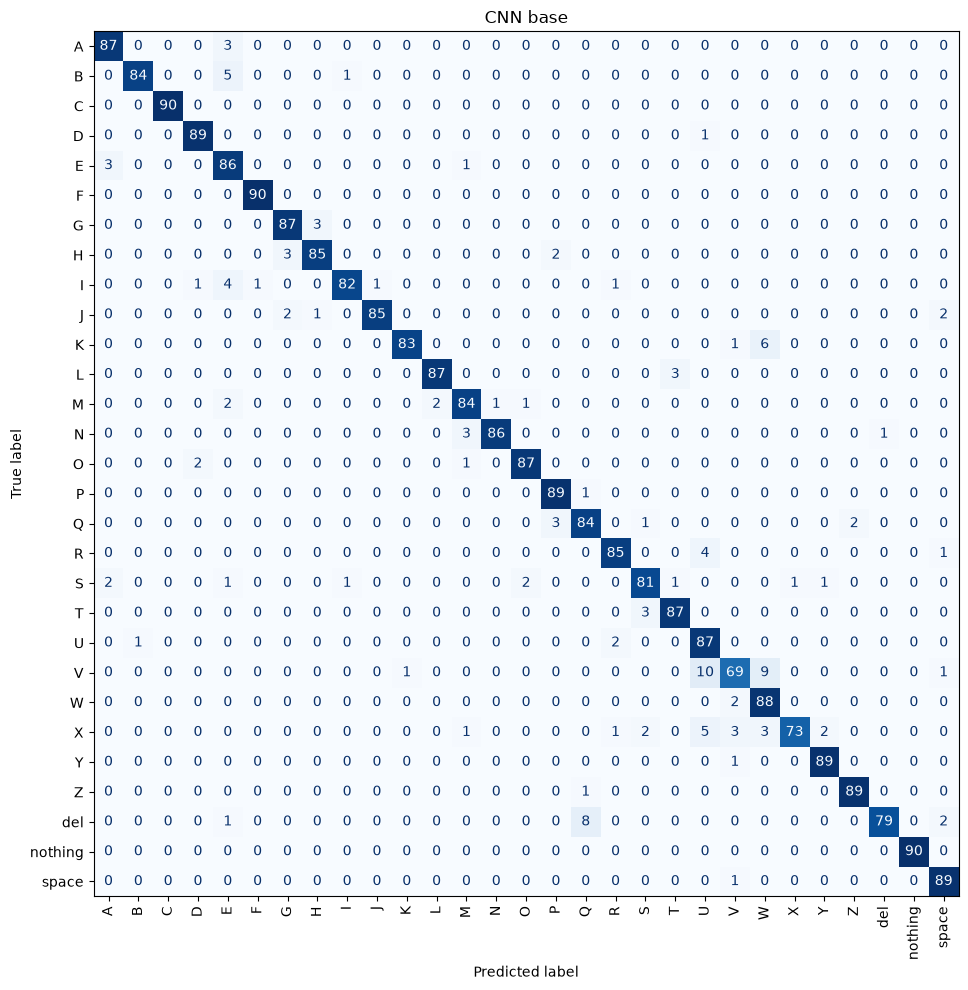

Pares mas confundidos en CNN base (real -> predicho: cantidad):
V -> U: 10
V -> W: 9
del -> Q: 8
K -> W: 6
B -> E: 5
X -> U: 5
I -> E: 4
R -> U: 4


In [17]:
y_pred_base = cnn_base.predict(X_test, verbose=0).argmax(axis=1)
cm_base = matriz_y_confusiones(y_test, y_pred_base, 'CNN base')

De las tres configuraciones que probamos, la que ganó fue learning rate de 0.001 con batch de 32, con 0.9395 de accuracy en validación tras 6 épocas, arriba del 0.9000 y el 0.8816 de las otras dos combinaciones. Con esa configuración entrenamos más épocas y el paro temprano cortó en la época 10 de las 18 que dejamos como tope. La red llegó a 0.9467 de accuracy en el set de prueba, con una pérdida de 0.1858.

La matriz de confusión coincide con lo que anotamos en el análisis exploratorio. Los dos pares que más se confunden son V con U, 10 imágenes, y V con W, 9, ambos dentro del grupo de dos dedos extendidos que marcamos como visualmente parecido. Después vienen del con Q, 8 imágenes, y K con W, 6. Ninguno pasa de 10 imágenes mal clasificadas sobre 90 posibles por clase, así que la confusión existe pero no domina el resultado.

### CNN profunda

In [18]:
def construir_cnn_profunda():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(64, 64, 3)),
        tf.keras.layers.Conv2D(32, 3, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(64, 3, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(128, 3, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Conv2D(256, 3, padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(29, activation='softmax'),
    ])

configuraciones_profunda = [
    {'learning_rate': 1e-3, 'batch_size': 64},
    {'learning_rate': 5e-4, 'batch_size': 64},
]

resultados_sweep_profunda = []
for config in configuraciones_profunda:
    modelo = construir_cnn_profunda()
    modelo.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=config['learning_rate']),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    historial = modelo.fit(X_train, y_train, validation_data=(X_val, y_val),
                             batch_size=config['batch_size'], epochs=6, verbose=0)
    val_acc = historial.history['val_accuracy'][-1]
    resultados_sweep_profunda.append({**config, 'val_accuracy': val_acc})
    print(f"lr={config['learning_rate']}, batch={config['batch_size']} -> val_accuracy={val_acc:.4f}")

mejor_config_profunda = max(resultados_sweep_profunda, key=lambda r: r['val_accuracy'])
print('\nMejor configuracion CNN profunda:', mejor_config_profunda)

lr=0.001, batch=64 -> val_accuracy=0.0345
lr=0.0005, batch=64 -> val_accuracy=0.3870

Mejor configuracion CNN profunda: {'learning_rate': 0.0005, 'batch_size': 64, 'val_accuracy': 0.38697317242622375}


In [19]:
cnn_profunda = construir_cnn_profunda()
cnn_profunda.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=mejor_config_profunda['learning_rate']),
                       loss='sparse_categorical_crossentropy', metrics=['accuracy'])

historial_profunda = cnn_profunda.fit(X_train, y_train, validation_data=(X_val, y_val),
                                        batch_size=mejor_config_profunda['batch_size'], epochs=18,
                                        callbacks=[crear_early_stop()], verbose=2)

test_loss_profunda, test_acc_profunda = cnn_profunda.evaluate(X_test, y_test, verbose=0)
print('\nCNN profunda, accuracy en prueba:', round(test_acc_profunda, 4))
print('CNN profunda, loss en prueba:', round(test_loss_profunda, 4))

Epoch 1/18
191/191 - 28s - 145ms/step - accuracy: 0.0867 - loss: 3.1750 - val_accuracy: 0.0345 - val_loss: 5.4980
Epoch 2/18
191/191 - 25s - 131ms/step - accuracy: 0.1663 - loss: 2.7034 - val_accuracy: 0.0368 - val_loss: 5.6267
Epoch 3/18
191/191 - 25s - 132ms/step - accuracy: 0.2440 - loss: 2.3140 - val_accuracy: 0.3724 - val_loss: 2.0790
Epoch 4/18
191/191 - 26s - 134ms/step - accuracy: 0.3108 - loss: 2.0343 - val_accuracy: 0.4548 - val_loss: 1.6617
Epoch 5/18
191/191 - 26s - 139ms/step - accuracy: 0.3717 - loss: 1.8204 - val_accuracy: 0.7249 - val_loss: 1.0982
Epoch 6/18
191/191 - 25s - 131ms/step - accuracy: 0.3940 - loss: 1.7168 - val_accuracy: 0.7762 - val_loss: 0.8275
Epoch 7/18
191/191 - 25s - 131ms/step - accuracy: 0.4212 - loss: 1.6083 - val_accuracy: 0.6793 - val_loss: 0.9534
Epoch 8/18
191/191 - 25s - 131ms/step - accuracy: 0.4317 - loss: 1.5517 - val_accuracy: 0.7165 - val_loss: 0.8569
Epoch 9/18
191/191 - 24s - 127ms/step - accuracy: 0.4520 - loss: 1.5061 - val_accuracy: 

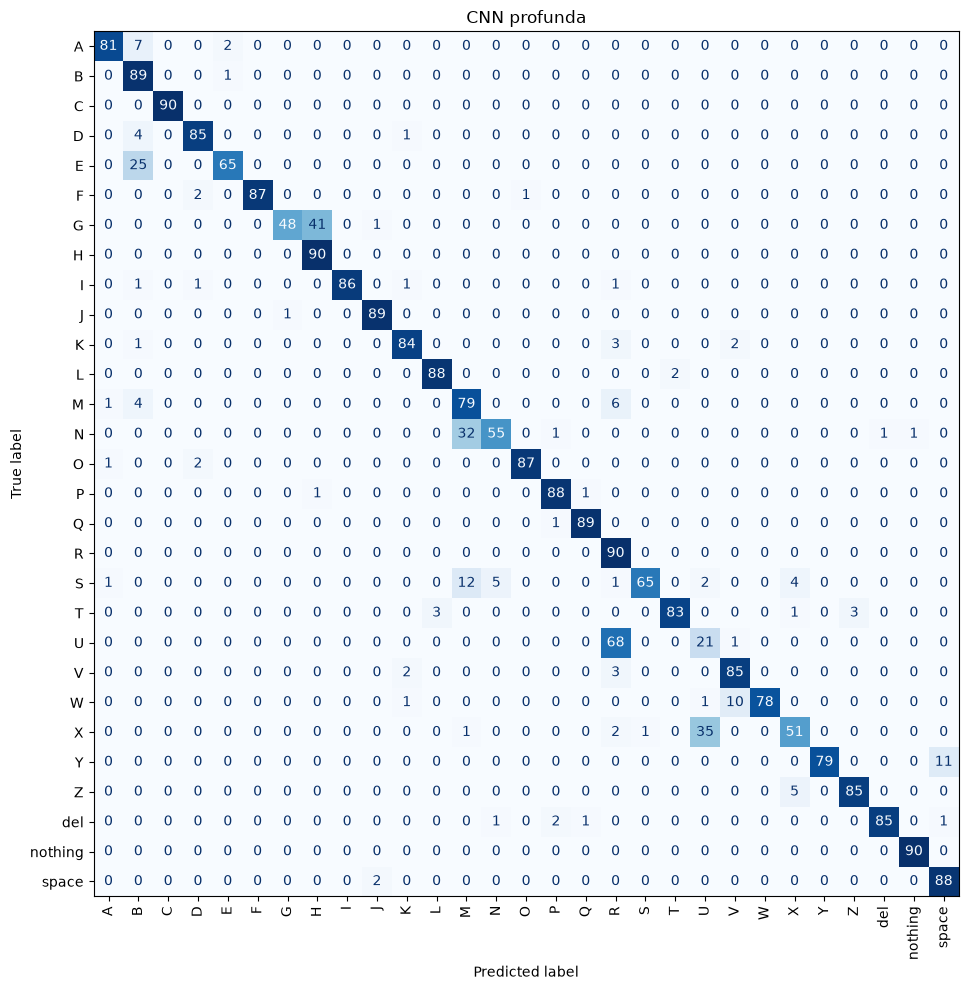

Pares mas confundidos en CNN profunda (real -> predicho: cantidad):
U -> R: 68
G -> H: 41
X -> U: 35
N -> M: 32
E -> B: 25
S -> M: 12
Y -> space: 11
W -> V: 10


In [20]:
y_pred_profunda = cnn_profunda.predict(X_test, verbose=0).argmax(axis=1)
cm_profunda = matriz_y_confusiones(y_test, y_pred_profunda, 'CNN profunda')

La CNN profunda quedó por debajo de la base. En el sweep, la configuración con learning rate de 0.001 colapsó a 0.0345 de accuracy en validación, cerca del nivel de adivinar al azar entre 29 clases, y la de 0.0005 se quedó en 0.3870 tras 6 épocas. Con esa segunda configuración entrenamos las 18 épocas completas sin que el paro temprano cortara antes, y la accuracy de entrenamiento terminó en 0.5309, mientras que la de validación fue inestable, subió a 0.9073 en la época 14 y cerró en 0.8858. La accuracy en prueba quedó en 0.8736, contra 0.9467 de la CNN base.

La explicación tiene dos partes. Agregar el cuarto bloque convolucional y la normalización por lotes hace la red más sensible al learning rate, como se ve en que 0.001 la hizo colapsar mientras que a la CNN base ese mismo valor le funcionó bien. Además la normalización por lotes se comporta distinto en modo entrenamiento, donde usa estadísticas del batch actual, que en modo evaluación, donde usa el promedio acumulado, y eso explica por qué la accuracy de entrenamiento se ve más baja que la de validación durante todo el entrenamiento. La matriz de confusión lo refleja, con U y R llegando a 68 imágenes mal clasificadas y G con H a 41, muy por encima de cualquier par de la CNN base. Con el presupuesto de épocas que usamos, la arquitectura más profunda no terminó de converger.

### Comparacion y seleccion de la mejor CNN

In [21]:
print('CNN base, accuracy en prueba:', round(test_acc_base, 4))
print('CNN profunda, accuracy en prueba:', round(test_acc_profunda, 4))

if test_acc_base >= test_acc_profunda:
    mejor_cnn = cnn_base
    nombre_mejor_cnn = 'CNN base'
    mejor_hparams_cnn = mejor_config_base
    construir_mejor_cnn = construir_cnn_base
    test_acc_mejor_cnn = test_acc_base
else:
    mejor_cnn = cnn_profunda
    nombre_mejor_cnn = 'CNN profunda'
    mejor_hparams_cnn = mejor_config_profunda
    construir_mejor_cnn = construir_cnn_profunda
    test_acc_mejor_cnn = test_acc_profunda

print('\nMejor CNN:', nombre_mejor_cnn, 'con accuracy en prueba de', round(test_acc_mejor_cnn, 4))

CNN base, accuracy en prueba: 0.9467
CNN profunda, accuracy en prueba: 0.8736

Mejor CNN: CNN base con accuracy en prueba de 0.9467


Nos quedamos con la CNN base para el resto de comparaciones. La diferencia entre 0.9467 y 0.8736 de accuracy en prueba es grande, y tiene que ver con que la arquitectura más profunda necesitaba más tiempo de entrenamiento del que le dimos. Con más épocas o un learning rate con calentamiento gradual la CNN profunda podría terminar superando a la base, pero dentro del presupuesto de cómputo de este laboratorio la base es la que funciona.

## Ejercicio 5: red neuronal simple

Entrenamos ahora la red totalmente conectada que describimos en la selección de modelos, sobre las mismas imágenes 64x64 en color, para comparar contra la mejor CNN.

In [22]:
def construir_fc():
    return tf.keras.Sequential([
        tf.keras.layers.Input(shape=(64, 64, 3)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(29, activation='softmax'),
    ])

fc = construir_fc()
fc.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss='sparse_categorical_crossentropy', metrics=['accuracy'])

historial_fc = fc.fit(X_train, y_train, validation_data=(X_val, y_val),
                        batch_size=64, epochs=18, callbacks=[crear_early_stop()], verbose=2)

test_loss_fc, test_acc_fc = fc.evaluate(X_test, y_test, verbose=0)
print('\nRed totalmente conectada, accuracy en prueba:', round(test_acc_fc, 4))
print('Red totalmente conectada, loss en prueba:', round(test_loss_fc, 4))

Epoch 1/18
191/191 - 4s - 23ms/step - accuracy: 0.0804 - loss: 3.4139 - val_accuracy: 0.1057 - val_loss: 3.1100
Epoch 2/18
191/191 - 4s - 19ms/step - accuracy: 0.1685 - loss: 2.8638 - val_accuracy: 0.1529 - val_loss: 2.9624
Epoch 3/18
191/191 - 4s - 19ms/step - accuracy: 0.2441 - loss: 2.5308 - val_accuracy: 0.1981 - val_loss: 2.6749
Epoch 4/18
191/191 - 4s - 19ms/step - accuracy: 0.3079 - loss: 2.2221 - val_accuracy: 0.2490 - val_loss: 2.5801
Epoch 5/18
191/191 - 4s - 21ms/step - accuracy: 0.3750 - loss: 1.9727 - val_accuracy: 0.3111 - val_loss: 2.1831
Epoch 6/18
191/191 - 3s - 18ms/step - accuracy: 0.4332 - loss: 1.7571 - val_accuracy: 0.3663 - val_loss: 1.9547
Epoch 7/18
191/191 - 3s - 17ms/step - accuracy: 0.4741 - loss: 1.6016 - val_accuracy: 0.3927 - val_loss: 1.8709
Epoch 8/18
191/191 - 4s - 20ms/step - accuracy: 0.5105 - loss: 1.4845 - val_accuracy: 0.4866 - val_loss: 1.5829
Epoch 9/18
191/191 - 4s - 19ms/step - accuracy: 0.5446 - loss: 1.3744 - val_accuracy: 0.5188 - val_loss:

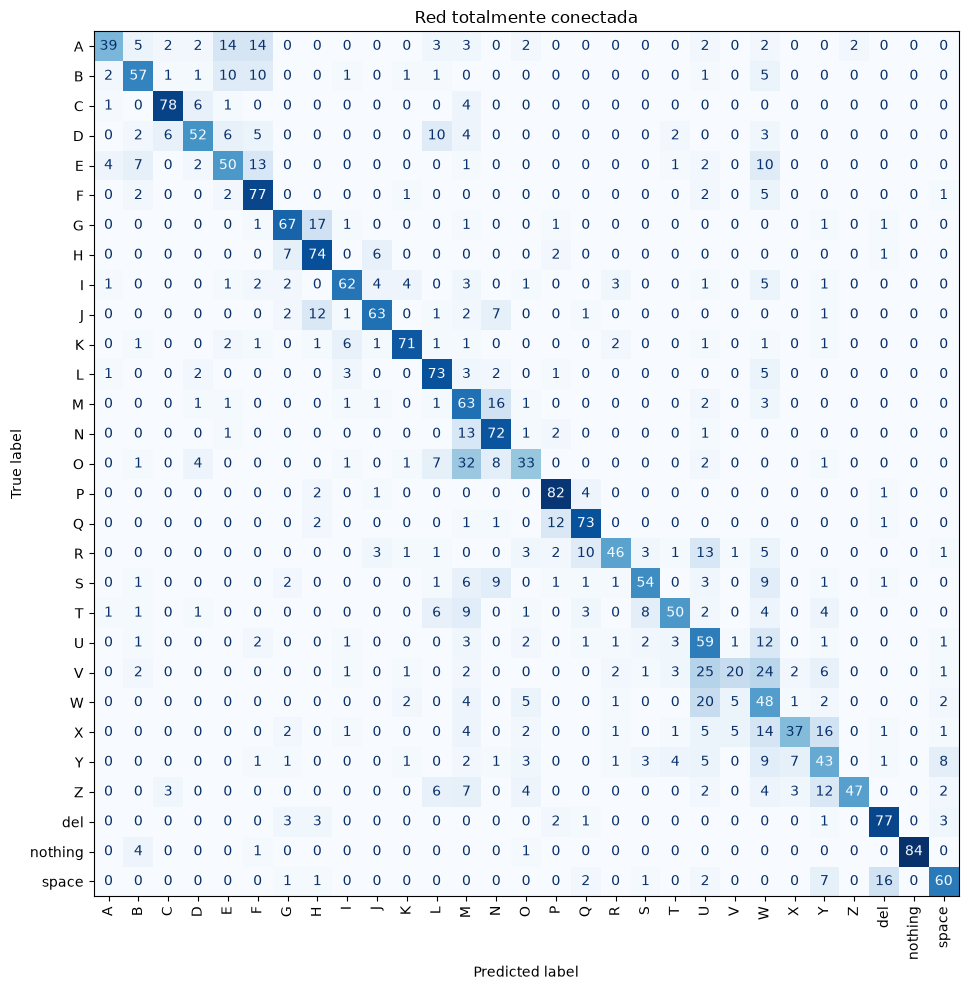

Pares mas confundidos en Red totalmente conectada (real -> predicho: cantidad):
O -> M: 32
V -> U: 25
V -> W: 24
W -> U: 20
G -> H: 17
M -> N: 16
X -> Y: 16
space -> del: 16


In [23]:
y_pred_fc = fc.predict(X_test, verbose=0).argmax(axis=1)
cm_fc = matriz_y_confusiones(y_test, y_pred_fc, 'Red totalmente conectada')

La red totalmente conectada llegó a 0.6556 de accuracy en prueba, muy por debajo de la CNN base y también de la CNN profunda. A diferencia de las CNN, no llegó a estabilizarse en 18 épocas: la accuracy de entrenamiento seguía subiendo al final, 0.6905, y la de validación cerró en 0.6498 sin señales de que el paro temprano fuera a cortar pronto.

La matriz de confusión es lo más revelador. Los pares que más confunde son O con M, 32 imágenes, V con U, 25, y V con W, 24, así que mezcla letras que sí marcamos como parecidas con otras que no tienen ninguna relación visual, como O con M. Esto encaja con lo que vimos en la imagen promedio por clase, donde la posición de la mano varía lo suficiente dentro de cada clase como para que un pixel en una posición fija no signifique lo mismo de una foto a otra. La red totalmente conectada trata cada pixel como una entrada independiente y no tiene forma de reconocer que un patrón de bordes es el mismo sin importar en qué parte de la imagen aparece, así que termina confundiendo letras por razones que no tienen que ver con el parecido real de la seña. Las CNN sí tienen esa invariancia espacial gracias a las convoluciones, y por eso les va mejor incluso cuando, como la CNN profunda, no terminan de converger.

## Ejercicio 6: algoritmo alterno, Random Forest

Ya justificamos en la selección de modelos por qué elegimos Random Forest sobre SVM o KNN para este problema: con miles de imágenes y vectores de más de 12000 valores, KNN sale caro en tiempo de predicción y SVM con kernel no lineal escala mal en tiempo de entrenamiento. Acá lo entrenamos sobre las imágenes aplanadas y vemos los resultados.

In [24]:
X_train_flat = X_train.reshape(len(X_train), -1)
X_val_flat = X_val.reshape(len(X_val), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

rf_base = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42, n_jobs=-1)
rf_base.fit(X_train_flat, y_train)

val_acc_rf_base = rf_base.score(X_val_flat, y_val)
test_acc_rf_base = rf_base.score(X_test_flat, y_test)
print('Random Forest base (200 arboles, sin limite de profundidad)')
print('accuracy en validacion:', round(val_acc_rf_base, 4))
print('accuracy en prueba:', round(test_acc_rf_base, 4))

Random Forest base (200 arboles, sin limite de profundidad)
accuracy en validacion: 0.9621
accuracy en prueba: 0.9582


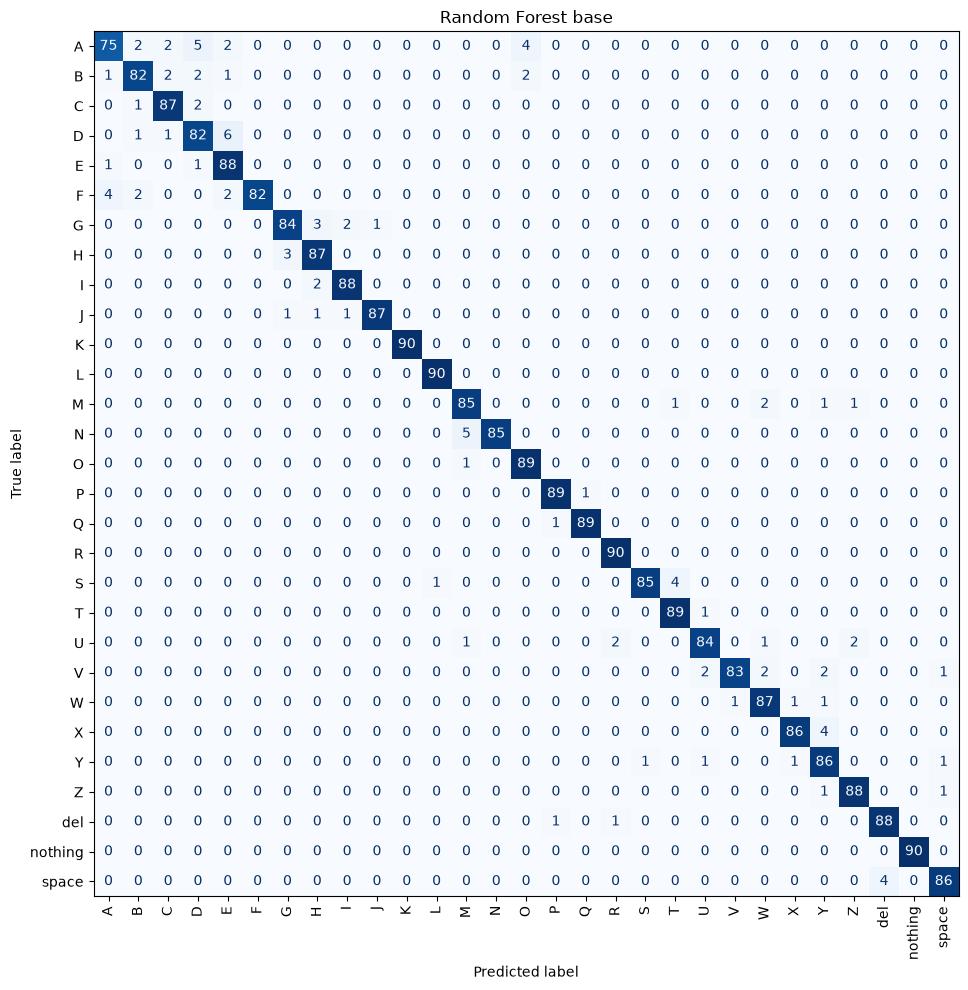

Pares mas confundidos en Random Forest base (real -> predicho: cantidad):
D -> E: 6
A -> D: 5
N -> M: 5
A -> O: 4
F -> A: 4
S -> T: 4
X -> Y: 4
space -> del: 4


In [25]:
y_pred_rf_base = rf_base.predict(X_test_flat)
cm_rf_base = matriz_y_confusiones(y_test, y_pred_rf_base, 'Random Forest base')

Con 200 árboles y sin límite de profundidad, el Random Forest llegó a 0.9621 de accuracy en validación y 0.9582 en prueba, ya por encima de la CNN base sin haber ajustado nada todavía. Trabaja sobre exactamente la misma representación de pixeles aplanados que la red totalmente conectada, que se quedó en 0.6556, así que la diferencia de más de 30 puntos está en el modelo y no en los datos que recibe.

Un árbol de decisión no necesita una regla global como una red densa. Cada árbol aprende reglas del tipo si el pixel en tal posición supera tal valor entonces probablemente es tal clase, y con cientos de árboles votando sobre subconjuntos distintos de pixeles el conjunto termina siendo bastante robusto. Esto conecta con la imagen promedio por clase: el fondo, la pared y el borde de la puerta salían casi idénticos entre clases porque la cámara estaba fija, así que hay pixeles de fondo consistentes que un árbol puede usar como referencia indirecta de dónde suele caer la mano, algo que una red totalmente conectada con descenso de gradiente no aprovecha igual de bien en el mismo número de épocas. La matriz de confusión sale limpia, el par que más se confunde, D con E, no pasa de 6 imágenes.

### Ajuste de parametros del Random Forest

In [26]:
configuraciones_rf = [
    {'n_estimators': 100, 'max_depth': None},
    {'n_estimators': 300, 'max_depth': None},
    {'n_estimators': 200, 'max_depth': 10},
    {'n_estimators': 200, 'max_depth': 20},
    {'n_estimators': 200, 'max_depth': 40},
]

resultados_rf = [{'n_estimators': 200, 'max_depth': None, 'val_accuracy': val_acc_rf_base}]
for config in configuraciones_rf:
    rf = RandomForestClassifier(n_estimators=config['n_estimators'], max_depth=config['max_depth'],
                                  random_state=42, n_jobs=-1)
    rf.fit(X_train_flat, y_train)
    val_acc = rf.score(X_val_flat, y_val)
    resultados_rf.append({**config, 'val_accuracy': val_acc})
    print(f"n_estimators={config['n_estimators']}, max_depth={config['max_depth']} -> val_accuracy={val_acc:.4f}")

mejor_config_rf = max(resultados_rf, key=lambda r: r['val_accuracy'])
print('\nMejor configuracion Random Forest:', mejor_config_rf)

n_estimators=100, max_depth=None -> val_accuracy=0.9579
n_estimators=300, max_depth=None -> val_accuracy=0.9640
n_estimators=200, max_depth=10 -> val_accuracy=0.9054
n_estimators=200, max_depth=20 -> val_accuracy=0.9582
n_estimators=200, max_depth=40 -> val_accuracy=0.9617

Mejor configuracion Random Forest: {'n_estimators': 300, 'max_depth': None, 'val_accuracy': 0.963984674329502}


Random Forest ajustado, accuracy en prueba: 0.9598
Random Forest base, accuracy en prueba: 0.9582


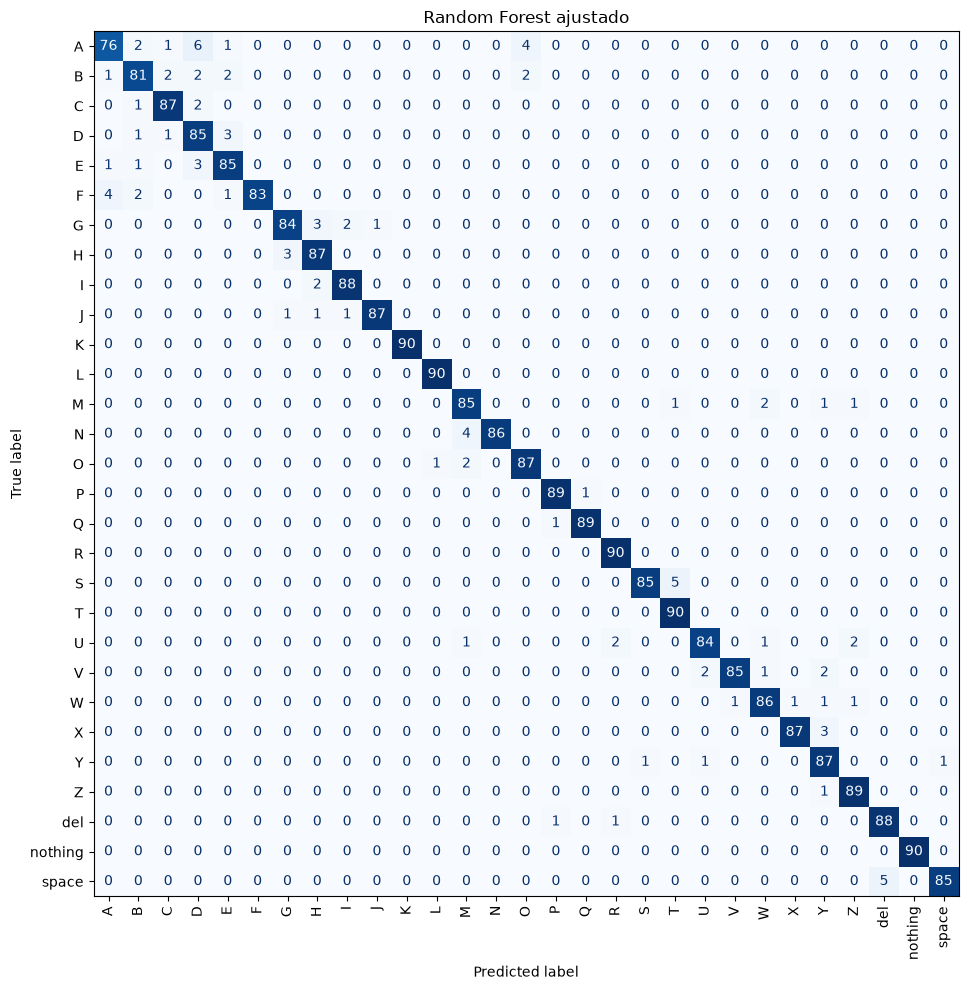

Pares mas confundidos en Random Forest ajustado (real -> predicho: cantidad):
A -> D: 6
S -> T: 5
space -> del: 5
A -> O: 4
F -> A: 4
N -> M: 4
D -> E: 3
E -> D: 3


In [27]:
rf_tuned = RandomForestClassifier(n_estimators=mejor_config_rf['n_estimators'],
                                    max_depth=mejor_config_rf['max_depth'],
                                    random_state=42, n_jobs=-1)
rf_tuned.fit(X_train_flat, y_train)

test_acc_rf_tuned = rf_tuned.score(X_test_flat, y_test)
print('Random Forest ajustado, accuracy en prueba:', round(test_acc_rf_tuned, 4))
print('Random Forest base, accuracy en prueba:', round(test_acc_rf_base, 4))

y_pred_rf_tuned = rf_tuned.predict(X_test_flat)
cm_rf_tuned = matriz_y_confusiones(y_test, y_pred_rf_tuned, 'Random Forest ajustado')

El parámetro que más movió la aguja fue la profundidad máxima, no la cantidad de árboles. Limitar la profundidad a 10 hundió la accuracy de validación a 0.9054, bastante por debajo del resto, mientras que 20 y 40 quedaron en 0.9582 y 0.9617, y las configuraciones sin límite se mantuvieron arriba de 0.957. Con 29 clases y más de 12000 variables de entrada, cada árbol necesita crecer bastante para separar las clases, así que cortar la profundidad le quita capacidad al modelo en vez de ayudarlo a generalizar.

La configuración ganadora fue 300 árboles sin límite de profundidad, con 0.9640 en validación. Entrenada sobre el set de entrenamiento completo dio 0.9598 en prueba, apenas arriba del 0.9582 del modelo base con 200 árboles. La mejora es pequeña pero real, y confirma que el Random Forest ya estaba cerca de su techo con la configuración inicial: la ganancia vino de subir el número de árboles, no de restringir el modelo.

## Ejercicio 7: image augmentation

Aplicamos ahora los aumentos que dejamos definidos en el plan de procesamiento de imágenes: rotaciones leves, corrimientos de posición, zoom leve y variaciones de brillo y contraste, solo sobre el conjunto de entrenamiento. Nada de flip.

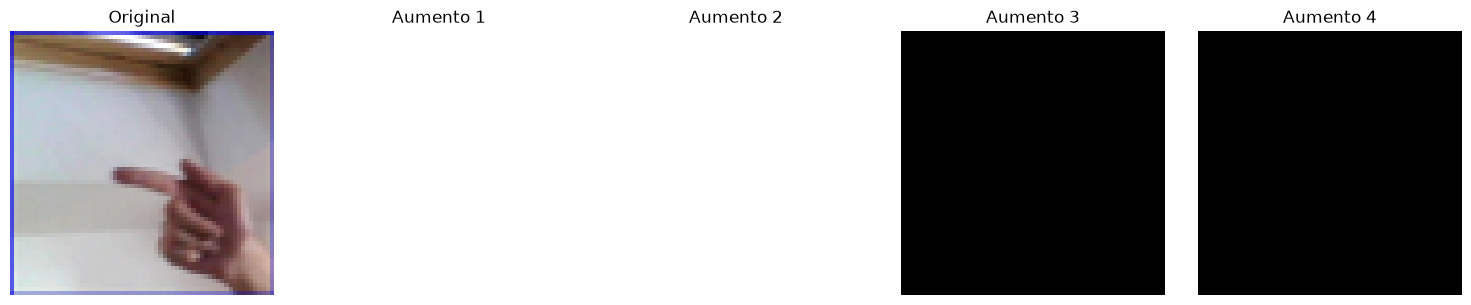

In [28]:
aumento = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(15 / 360),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomBrightness(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name='aumento_datos')

imagen_muestra = X_train[0:1]
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(imagen_muestra[0])
axes[0].set_title('Original')
axes[0].axis('off')
for i in range(1, 5):
    aumentada = aumento(imagen_muestra, training=True).numpy()
    aumentada = np.clip(aumentada, 0.0, 1.0)
    axes[i].imshow(aumentada[0])
    axes[i].set_title(f'Aumento {i}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

In [29]:
X_train_aumentado = aumento(X_train, training=True).numpy()
X_train_aumentado = np.clip(X_train_aumentado, 0.0, 1.0)

X_train_combinado = np.concatenate([X_train, X_train_aumentado], axis=0)
y_train_combinado = np.concatenate([y_train, y_train], axis=0)

print('Forma set de entrenamiento original:', X_train.shape)
print('Forma set de entrenamiento con aumento:', X_train_combinado.shape)

Forma set de entrenamiento original: (12180, 64, 64, 3)
Forma set de entrenamiento con aumento: (24360, 64, 64, 3)


In [30]:
cnn_aumentada = construir_mejor_cnn()
cnn_aumentada.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=mejor_hparams_cnn['learning_rate']),
                        loss='sparse_categorical_crossentropy', metrics=['accuracy'])

historial_cnn_aumentada = cnn_aumentada.fit(X_train_combinado, y_train_combinado,
                                              validation_data=(X_val, y_val),
                                              batch_size=mejor_hparams_cnn['batch_size'], epochs=18,
                                              callbacks=[crear_early_stop()], verbose=2)

test_loss_cnn_aumentada, test_acc_cnn_aumentada = cnn_aumentada.evaluate(X_test, y_test, verbose=0)
print(f'\n{nombre_mejor_cnn} con aumento, accuracy en prueba:', round(test_acc_cnn_aumentada, 4))
print(f'{nombre_mejor_cnn} sin aumento, accuracy en prueba:', round(test_acc_mejor_cnn, 4))

Epoch 1/18
762/762 - 24s - 31ms/step - accuracy: 0.1794 - loss: 2.8409 - val_accuracy: 0.6303 - val_loss: 1.1873
Epoch 2/18
762/762 - 21s - 27ms/step - accuracy: 0.4207 - loss: 1.9889 - val_accuracy: 0.8605 - val_loss: 0.4494
Epoch 3/18
762/762 - 21s - 28ms/step - accuracy: 0.4775 - loss: 1.7979 - val_accuracy: 0.8939 - val_loss: 0.3372
Epoch 4/18
762/762 - 21s - 27ms/step - accuracy: 0.5000 - loss: 1.7330 - val_accuracy: 0.9080 - val_loss: 0.2971
Epoch 5/18
762/762 - 20s - 27ms/step - accuracy: 0.5078 - loss: 1.7041 - val_accuracy: 0.9238 - val_loss: 0.2471
Epoch 6/18
762/762 - 20s - 26ms/step - accuracy: 0.5128 - loss: 1.6955 - val_accuracy: 0.9184 - val_loss: 0.3032
Epoch 7/18
762/762 - 21s - 27ms/step - accuracy: 0.5181 - loss: 1.6783 - val_accuracy: 0.9295 - val_loss: 0.2461
Epoch 8/18
762/762 - 20s - 26ms/step - accuracy: 0.5227 - loss: 1.6708 - val_accuracy: 0.9502 - val_loss: 0.1897
Epoch 9/18
762/762 - 20s - 27ms/step - accuracy: 0.5203 - loss: 1.6790 - val_accuracy: 0.9621 - 

In [31]:
fc_aumentada = construir_fc()
fc_aumentada.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                       loss='sparse_categorical_crossentropy', metrics=['accuracy'])

historial_fc_aumentada = fc_aumentada.fit(X_train_combinado, y_train_combinado,
                                            validation_data=(X_val, y_val),
                                            batch_size=64, epochs=18,
                                            callbacks=[crear_early_stop()], verbose=2)

test_loss_fc_aumentada, test_acc_fc_aumentada = fc_aumentada.evaluate(X_test, y_test, verbose=0)
print('\nRed totalmente conectada con aumento, accuracy en prueba:', round(test_acc_fc_aumentada, 4))
print('Red totalmente conectada sin aumento, accuracy en prueba:', round(test_acc_fc, 4))

Epoch 1/18
381/381 - 8s - 21ms/step - accuracy: 0.0490 - loss: 3.5356 - val_accuracy: 0.0824 - val_loss: 3.2710
Epoch 2/18
381/381 - 8s - 22ms/step - accuracy: 0.0625 - loss: 3.2709 - val_accuracy: 0.1192 - val_loss: 3.0214
Epoch 3/18
381/381 - 8s - 22ms/step - accuracy: 0.0985 - loss: 3.0915 - val_accuracy: 0.1747 - val_loss: 2.6449
Epoch 4/18
381/381 - 8s - 21ms/step - accuracy: 0.1400 - loss: 2.9128 - val_accuracy: 0.2594 - val_loss: 2.4194
Epoch 5/18
381/381 - 8s - 22ms/step - accuracy: 0.1765 - loss: 2.7664 - val_accuracy: 0.3333 - val_loss: 2.1187
Epoch 6/18
381/381 - 7s - 18ms/step - accuracy: 0.2029 - loss: 2.6543 - val_accuracy: 0.3866 - val_loss: 1.9243
Epoch 7/18
381/381 - 8s - 20ms/step - accuracy: 0.2281 - loss: 2.5646 - val_accuracy: 0.4479 - val_loss: 1.7312
Epoch 8/18
381/381 - 7s - 19ms/step - accuracy: 0.2430 - loss: 2.5053 - val_accuracy: 0.4464 - val_loss: 1.6729
Epoch 9/18
381/381 - 7s - 19ms/step - accuracy: 0.2673 - loss: 2.4289 - val_accuracy: 0.4536 - val_loss:

In [32]:
X_train_combinado_flat = X_train_combinado.reshape(len(X_train_combinado), -1)

rf_aumentado = RandomForestClassifier(n_estimators=mejor_config_rf['n_estimators'],
                                        max_depth=mejor_config_rf['max_depth'],
                                        random_state=42, n_jobs=-1)
rf_aumentado.fit(X_train_combinado_flat, y_train_combinado)

test_acc_rf_aumentado = rf_aumentado.score(X_test_flat, y_test)
print('Random Forest con aumento, accuracy en prueba:', round(test_acc_rf_aumentado, 4))
print('Random Forest sin aumento, accuracy en prueba:', round(test_acc_rf_tuned, 4))

Random Forest con aumento, accuracy en prueba: 0.9605
Random Forest sin aumento, accuracy en prueba: 0.9598


In [33]:
comparacion_aumento = pd.DataFrame({
    'modelo': [nombre_mejor_cnn, 'Red totalmente conectada', 'Random Forest'],
    'accuracy_prueba_sin_aumento': [test_acc_mejor_cnn, test_acc_fc, test_acc_rf_tuned],
    'accuracy_prueba_con_aumento': [test_acc_cnn_aumentada, test_acc_fc_aumentada, test_acc_rf_aumentado],
})
comparacion_aumento['diferencia'] = comparacion_aumento['accuracy_prueba_con_aumento'] - comparacion_aumento['accuracy_prueba_sin_aumento']
comparacion_aumento

,modelo,accuracy_prueba_sin_aumento,accuracy_prueba_con_aumento,diferencia
0,CNN base,0.946743,0.956705,0.009962
1,Red totalmente conectada,0.655556,0.613027,-0.042529
2,Random Forest,0.959770,0.960536,0.000766


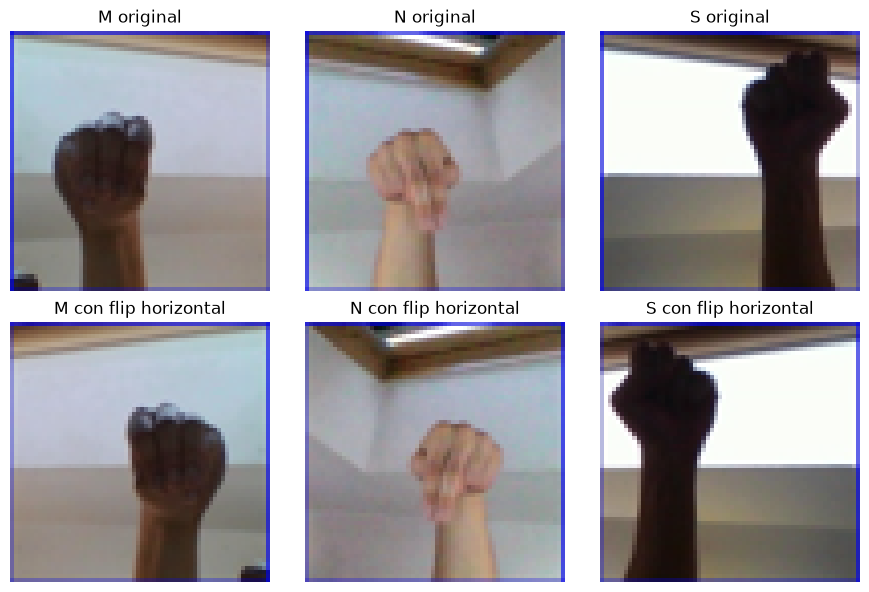

In [34]:
clases_flip_demo = ['M', 'N', 'S']
fig, axes = plt.subplots(2, len(clases_flip_demo), figsize=(9, 6))

for j, clase in enumerate(clases_flip_demo):
    idx = np.where(y_test == clase_a_indice[clase])[0][0]
    imagen = X_test[idx]
    imagen_flip = np.fliplr(imagen)

    axes[0, j].imshow(imagen)
    axes[0, j].set_title(f'{clase} original')
    axes[0, j].axis('off')

    axes[1, j].imshow(imagen_flip)
    axes[1, j].set_title(f'{clase} con flip horizontal')
    axes[1, j].axis('off')

plt.tight_layout()
plt.show()

El aumento no le hizo lo mismo a los tres modelos. La CNN base subió de 0.9467 a 0.9567 de accuracy en prueba, un punto porcentual, el Random Forest pasó de 0.9598 a 0.9605, menos de un décimo de punto, y la red totalmente conectada bajó de 0.6556 a 0.6130. Durante el entrenamiento de la CNN aumentada la accuracy de entrenamiento se quedó alrededor de 0.52 mientras la de validación llegó a 0.9621, que es lo esperable: el set de entrenamiento aumentado mezcla las imágenes originales con las rotadas, corridas y con brillo alterado, más difíciles de clasificar, mientras que validación sigue siendo el set limpio de siempre.

Que la CNN sea la que más se beneficia tiene sentido porque es la única de las tres que aprende filtros espaciales, y esos filtros se vuelven más robustos viendo la misma mano en distintas posiciones y ángulos. La red totalmente conectada no tiene esa estructura para aprovechar la variedad extra, trata cada pixel como independiente, así que las variaciones no le enseñan invariancia y terminan actuando como ruido, que es justo lo que muestra su caída de 4 puntos. El Random Forest tampoco se movió, porque ya estaba cerca de su techo con esta representación de pixeles aplanados y las reglas de corte por pixel que aprende no generalizan mejor por duplicar el set con versiones desplazadas de las mismas imágenes.

Sobre por qué el flip horizontal es distinto a los demás aumentos: en las imágenes de M, N y S volteadas horizontalmente, la mano sigue pareciendo una mano, pero el orden de izquierda a derecha de los dedos y el pulgar queda invertido. Estas señas se distinguen exactamente por esa posición relativa del pulgar contra los demás dedos, y N con M aparece con 32 imágenes mal clasificadas en la CNN profunda, uno de sus pares más confundidos. Voltear la imagen no agrega una variación de cámara como sí lo hacen la rotación leve o el corrimiento de posición, cambia la geometría misma de la seña, y podría acercar visualmente una M volteada a como luce una N o una S real, metiendo una señal falsa justo en el par que el modelo ya tiene más difícil. Rotar unos grados o mover la mano unos pixeles sigue siendo la misma seña vista con otro encuadre, mientras que el flip cambia qué seña es.

Por esto los aumentos que sí aplicamos son rotación leve, hasta 15 grados, corrimiento de posición, zoom leve y variaciones de brillo y contraste, todos aumentos que simulan variabilidad de cómo se capturó la foto y no de la forma de la mano. Rotaciones más grandes también las evitamos, porque igual que el flip podrían acercar una seña a otra dentro de los grupos M, N, S y U, V, R que identificamos desde el análisis exploratorio. El flip horizontal y vertical quedan fuera por completo, porque ninguno de los dos representa una variación real de cómo alguien haría esa seña frente a una cámara, invierten la seña misma.

## Consolidacion de los ejercicios 4 a 7

In [35]:
resumen_final = pd.DataFrame({
    'modelo': ['CNN base', 'CNN profunda', 'Red totalmente conectada', 'Random Forest base', 'Random Forest ajustado',
               f'{nombre_mejor_cnn} con aumento', 'Red totalmente conectada con aumento', 'Random Forest con aumento'],
    'accuracy_prueba': [test_acc_base, test_acc_profunda, test_acc_fc, test_acc_rf_base, test_acc_rf_tuned,
                         test_acc_cnn_aumentada, test_acc_fc_aumentada, test_acc_rf_aumentado],
})
resumen_final = resumen_final.sort_values('accuracy_prueba', ascending=False).reset_index(drop=True)
resumen_final

,modelo,accuracy_prueba
0,Random Forest con aumento,0.960536
1,Random Forest ajustado,0.959770
2,Random Forest base,0.958238
3,CNN base con aumento,0.956705
4,CNN base,0.946743
5,CNN profunda,0.873563
6,Red totalmente conectada,0.655556
7,Red totalmente conectada con aumento,0.613027


Con los ocho modelos ordenados, arriba quedan el Random Forest con aumento con 0.9605, el Random Forest ajustado con 0.9598 y el Random Forest base con 0.9582, y muy cerca la CNN base con aumento con 0.9567. Estos cuatro quedan a menos de medio punto porcentual entre sí. Después viene la CNN base sin aumento con 0.9467, y ya en otro nivel la CNN profunda con 0.8736 y la red totalmente conectada, entre 0.6556 y 0.6130 según si lleva aumento o no.

Que el Random Forest termine arriba no significa que sea el mejor modelo para el problema real de clasificar señas. Buena parte de su desempeño puede venir de aprovechar pixeles de fondo consistentes entre clases, porque las fotos de este dataset se tomaron con la misma cámara fija, algo que ya se veía en la imagen promedio por clase. Ese patrón no necesariamente se sostiene con fotos nuevas tomadas en otras condiciones, mientras que la CNN aprende filtros que reconocen la forma de la mano sin depender tanto del fondo. Por eso seguimos considerando tanto el Random Forest ajustado como la CNN base con aumento como candidatos serios, en vez de descartar la CNN solo por haber quedado unas décimas abajo en este set de prueba particular.

De los cuatro ejercicios, el patrón que más se repite es que la arquitectura por sí sola no garantiza nada sin el ajuste de parámetros y sin pensar qué tipo de variación tiene sentido agregarle a los datos. La CNN profunda con más capas no le ganó a la más simple porque no tuvo suficiente entrenamiento para converger, el Random Forest mejoró más por ampliar el número de árboles que por restringir su profundidad, y el aumento de datos solo ayudó al modelo que tenía la estructura para aprovecharlo. El paso que sigue es ver qué hacen estos dos candidatos con fotos tomadas fuera del dataset.

## Ejercicio 8: prueba con senas propias

Para ver si los dos candidatos generalizan fuera del dataset de Kaggle, tomamos fotos de nuestras propias manos haciendo señas del alfabeto ASL, con fondo e iluminación distintos a los del dataset original. Antes de tomarlas generamos una hoja de referencia con imágenes reales del dataset para saber exactamente qué forma imitar.

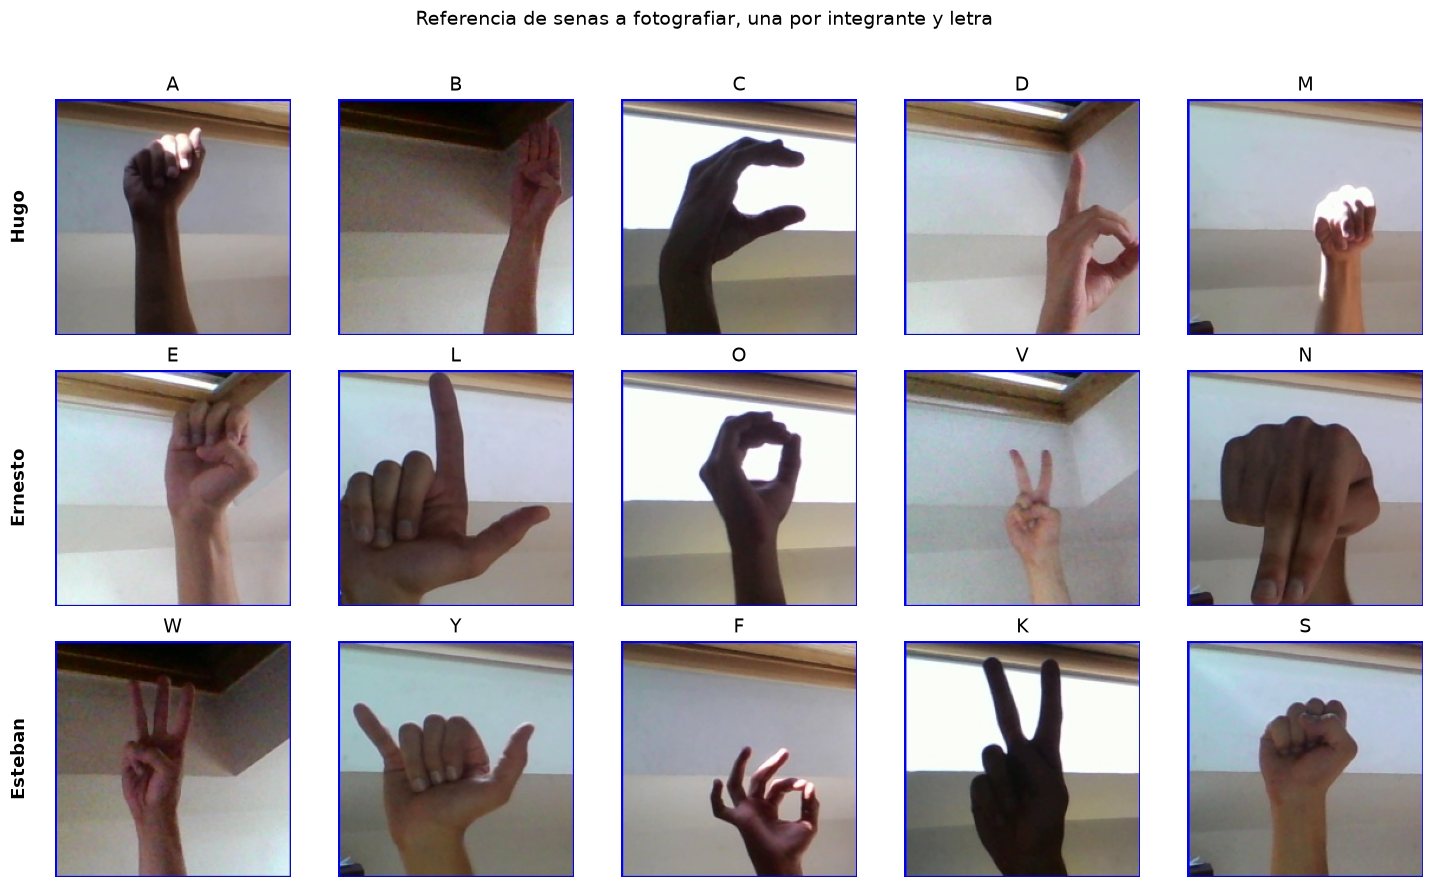

In [36]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

asignacion_senas = {
    'Hugo': ['A', 'B', 'C', 'D', 'M'],
    'Ernesto': ['E', 'L', 'O', 'V', 'N'],
    'Esteban': ['W', 'Y', 'F', 'K', 'S'],
}

fig, axes = plt.subplots(len(asignacion_senas), 5, figsize=(15, 9))

for i, (integrante, letras_asignadas) in enumerate(asignacion_senas.items()):
    for j, letra in enumerate(letras_asignadas):
        letra_path = os.path.join(base_path, letra)
        img_name = os.listdir(letra_path)[0]
        img = mpimg.imread(os.path.join(letra_path, img_name))
        ax = axes[i, j]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(letra, fontsize=14)
        if j == 0:
            ax.text(-0.15, 0.5, integrante, transform=ax.transAxes, rotation=90,
                    va='center', ha='center', fontsize=13, fontweight='bold')

plt.suptitle('Referencia de senas a fotografiar, una por integrante y letra', fontsize=14)
plt.tight_layout(rect=[0.02, 0, 1, 0.96])
plt.show()


In [37]:
from PIL import ImageOps
import re

data_propias_path = '../data_propias'

def cargar_data_propias(carpeta):
    rutas_letra = []
    rutas_integrante = []
    rutas_archivo = []
    for nombre_archivo in sorted(os.listdir(carpeta)):
        ruta_completa = os.path.join(carpeta, nombre_archivo)
        if os.path.isdir(ruta_completa):
            letra = nombre_archivo.upper()
            for sub_archivo in sorted(os.listdir(ruta_completa)):
                integrante = sub_archivo.split('_')[0].split('.')[0].lower() if '_' in sub_archivo else 'desconocido'
                rutas_letra.append(letra)
                rutas_integrante.append(integrante)
                rutas_archivo.append(os.path.join(ruta_completa, sub_archivo))
        else:
            match = re.match(r'([A-Za-z]+)_?(\w*)', os.path.splitext(nombre_archivo)[0])
            letra = match.group(1).upper()
            integrante = match.group(2).lower() if match.group(2) else 'desconocido'
            rutas_letra.append(letra)
            rutas_integrante.append(integrante)
            rutas_archivo.append(ruta_completa)

    X = np.zeros((len(rutas_archivo), 64, 64, 3), dtype=np.float32)
    y = np.zeros(len(rutas_archivo), dtype=np.int32)
    for i, ruta in enumerate(rutas_archivo):
        img = ImageOps.exif_transpose(Image.open(ruta)).convert('RGB')
        ancho, alto = img.size
        lado = min(ancho, alto)
        izquierda = (ancho - lado) // 2
        arriba = (alto - lado) // 2
        img = img.crop((izquierda, arriba, izquierda + lado, arriba + lado)).resize((64, 64))
        X[i] = np.array(img) / 255.0
        y[i] = clase_a_indice[rutas_letra[i]]
    return X, y, rutas_letra, rutas_integrante

X_propias, y_propias, letras_propias, integrantes_propias = cargar_data_propias(data_propias_path)
print('Fotos propias cargadas:', len(X_propias))
print('Integrantes:', sorted(set(integrantes_propias)))
print('Letras:', sorted(set(letras_propias)))


Fotos propias cargadas: 22
Integrantes: ['ernesto', 'esteban']
Letras: ['A', 'B', 'C', 'D', 'E', 'F', 'H', 'J', 'K', 'L', 'M', 'N', 'O', 'Q', 'S', 'V', 'W', 'Y']


In [38]:
X_propias_flat = X_propias.reshape(len(X_propias), -1)

pred_rf_propias = rf_tuned.predict(X_propias_flat)
pred_cnn_propias = cnn_aumentada.predict(X_propias, verbose=0).argmax(axis=1)

resultados_propias = pd.DataFrame({
    'integrante': integrantes_propias,
    'letra_real': letras_propias,
    'pred_rf': [clases[i] for i in pred_rf_propias],
    'pred_cnn': [clases[i] for i in pred_cnn_propias],
})
resultados_propias['acierto_rf'] = resultados_propias['letra_real'] == resultados_propias['pred_rf']
resultados_propias['acierto_cnn'] = resultados_propias['letra_real'] == resultados_propias['pred_cnn']

accuracy_rf_propias = resultados_propias['acierto_rf'].mean()
accuracy_cnn_propias = resultados_propias['acierto_cnn'].mean()

print('Random Forest ajustado, accuracy en fotos propias:', round(accuracy_rf_propias, 4),
      f"({resultados_propias['acierto_rf'].sum()}/{len(resultados_propias)})")
print('CNN base con aumento, accuracy en fotos propias:', round(accuracy_cnn_propias, 4),
      f"({resultados_propias['acierto_cnn'].sum()}/{len(resultados_propias)})")
resultados_propias


Random Forest ajustado, accuracy en fotos propias: 0.0 (0/22)
CNN base con aumento, accuracy en fotos propias: 0.0909 (2/22)


,integrante,letra_real,pred_rf,pred_cnn,acierto_rf,acierto_cnn
0,ernesto,A,nothing,L,False,False
1,esteban,A,H,Z,False,False
2,ernesto,B,nothing,L,False,False
3,ernesto,C,nothing,L,False,False
4,ernesto,D,nothing,L,False,False
5,ernesto,E,nothing,L,False,False
6,ernesto,F,nothing,L,False,False
7,esteban,H,nothing,H,False,True
8,esteban,J,P,Y,False,False
9,ernesto,K,nothing,T,False,False


In [39]:
print('Desglose por integrante:')
print(resultados_propias.groupby('integrante')[['acierto_rf', 'acierto_cnn']].mean())

print('\nFotos donde fallo el Random Forest:')
print(resultados_propias[~resultados_propias['acierto_rf']][['integrante', 'letra_real', 'pred_rf']])

print('\nFotos donde fallo la CNN:')
print(resultados_propias[~resultados_propias['acierto_cnn']][['integrante', 'letra_real', 'pred_cnn']])


Desglose por integrante:
            acierto_rf  acierto_cnn
integrante                         
ernesto            0.0     0.066667
esteban            0.0     0.142857

Fotos donde fallo el Random Forest:
   integrante letra_real  pred_rf
0     ernesto          A  nothing
1     esteban          A        H
2     ernesto          B  nothing
3     ernesto          C  nothing
4     ernesto          D  nothing
5     ernesto          E  nothing
6     ernesto          F  nothing
7     esteban          H  nothing
8     esteban          J        P
9     ernesto          K  nothing
10    ernesto          L  nothing
11    ernesto          M  nothing
12    esteban          M        H
13    ernesto          N  nothing
14    ernesto          O  nothing
15    esteban          O        H
16    esteban          Q        H
17    ernesto          S  nothing
18    ernesto          V  nothing
19    esteban          V  nothing
20    ernesto          W  nothing
21    ernesto          Y  nothing

Fotos donde

Cargamos 22 fotos que cubren 18 letras y vienen de dos conjuntos de captura distintos. El Random Forest ajustado acertó 0 de 22 y la CNN base con aumento acertó 2 de 22, un 0.0909. Contra el 0.9598 y el 0.9567 que estos mismos modelos dieron en el set de prueba del dataset, la caída es total. Los modelos no generalizan a fotos tomadas en condiciones distintas a las del dataset original, aunque en el set de prueba se vean casi perfectos.

Los dos conjuntos de fotos se tomaron en condiciones bastante distintas y eso cambia la forma del error. En uno la mano ocupa una porción chica del cuadro y el resto es pared, techo, mueble y hombro. En el otro la mano está mucho más cerca del lente y llena buena parte del cuadro, sobre un fondo de madera más oscuro y con menos contraste. Esa diferencia de encuadre es la que mejor explica lo que hace cada modelo.

El Random Forest predijo nothing en 17 de las 22 fotos. Las 15 del conjunto con más fondo cayeron todas en nothing, sin excepción. La clase nothing del dataset son fotos de pared y techo vacíos, con el mismo tono de pared y la misma luz que aparece de fondo en nuestras fotos, y es además la clase con el brillo promedio y la desviación más altos de las que medimos en el análisis exploratorio, 146.9 y 29.5. En el dataset la mano llena casi todo el cuadro, así que cuando la proporción de fondo crece el modelo se queda sin la señal que estaba usando y la foto se le parece más a una escena vacía que a una seña. En el conjunto donde la mano está cerca del lente el comportamiento cambia: solo 2 de 7 fotos cayeron en nothing y las otras 5 recibieron letras, cuatro veces H y una vez P. Sigue siendo 0 aciertos, pero deja de contestar que no hay mano. El Random Forest no depende de un fondo específico, depende de que el fondo sea mínimo.

La CNN con aumento falló distinto y también cambió según el encuadre. En el conjunto con más fondo predijo L en 14 de 15 fotos sin importar la seña real, y su único acierto ahí fue justamente cuando la foto era una L. Ese colapso a una salida por defecto es típico de un modelo que se enfrenta a datos muy fuera de lo que vio en entrenamiento, no de un modelo que esté leyendo la forma de la mano. En el conjunto con la mano más cerca las 7 predicciones fueron 7 letras distintas, Z, H, Y, W, B, P y R, con la H acertada. Deja de repetir siempre lo mismo y empieza a reaccionar a la forma, aunque casi siempre se equivoque. El aumento que aplicamos, rotación, zoom, brillo y contraste, ayuda contra variaciones pequeñas pero no prepara al modelo para un encuadre con esta cantidad de fondo extra ni para un ángulo de cámara tan distinto al de un dataset tomado con la mano pegada al lente.

Cuatro letras, A, M, O y V, quedaron fotografiadas en los dos conjuntos, con manos distintas y en fondos e iluminaciones distintas. Ninguna de esas ocho fotos la acertó ninguno de los dos modelos. Lo que cambia no es el acierto sino el tipo de error: en las cuatro del conjunto con más fondo el Random Forest respondió nothing y la CNN respondió L, mientras que en las cuatro del otro conjunto el Random Forest respondió H en tres y nothing en la V, y la CNN respondió Z, W, B y R. La misma seña, hecha por dos manos en dos escenarios, produce errores de naturaleza distinta según las condiciones de captura y no según la letra.

El análisis se completa cuando se sumen las fotos del integrante restante y haya un tercer conjunto de condiciones para contrastar.

## Ejercicio 9: accesibilidad y sesgo

Lo que salió en el ejercicio 8 muestra limitaciones fuertes de este dataset para pensar en un producto real de accesibilidad como SignBridge.

El ángulo de cámara y la distancia son el problema más evidente. Las 17400 imágenes del dataset se tomaron con la mano pegada al lente, llenando casi todo el cuadro, con un fondo fijo de pared y techo. Nuestras fotos, tomadas con celular a una distancia normal de uso, tienen mucho más fondo alrededor de la mano. Esa sola diferencia de encuadre bastó para que el Random Forest cayera a 0 de 22 y la CNN a 2 de 22, contra el 0.9598 y el 0.9567 del set de prueba. Un producto real no puede asumir que el usuario va a sostener la mano exactamente a la misma distancia y ángulo que se usó para entrenar.

Tener dos conjuntos de fotos permite separar un poco el efecto. En el conjunto donde la mano ocupa poca parte del cuadro, el Random Forest respondió nothing en las 15 fotos y la CNN respondió L en 14 de 15. En el conjunto donde la mano está cerca del lente, el Random Forest dejó de responder nothing en 5 de 7 y la CNN dio 7 letras distintas en vez de repetir una sola, con la accuracy subiendo de 0.0667 a 0.1429. Ninguno de los dos se vuelve usable, pero la proporción de mano dentro del cuadro cambia claramente cómo se comporta el modelo, y es la variable de captura con el efecto más visible de las que pudimos medir.

La iluminación también difiere entre los dos conjuntos, uno más claro y otro notablemente más oscuro y con menos contraste, pero con 22 fotos y dos escenarios no se puede separar su efecto del efecto del encuadre, porque las dos cosas cambian juntas. Lo mismo pasa con el tono de piel y el tamaño de mano: son dos manos distintas, y el dataset original tampoco documenta de dónde salieron las manos que aparecen en sus fotos. Las cuatro letras fotografiadas en los dos conjuntos, A, M, O y V, fallaron en las ocho fotos con los dos modelos, así que ninguna condición rescata a la otra, solo cambia el tipo de error. Con este tamaño de muestra no podemos afirmar que el modelo responda distinto según tono de piel o tamaño de mano, pero sí que es tan sensible a variables de captura que nadie controló al armar el dataset que sería raro que estas otras no lo afectaran.

Para llevar este prototipo a un caso de uso real hace falta bastante más que ajustar hiperparámetros. Se necesitan datos recolectados en condiciones variadas a propósito, con distintas cámaras, distancias, fondos, iluminaciones, tonos de piel y tamaños de mano, en vez de una sola sesión de fotos con una cámara fija. También hace falta una forma de medir qué tan bien funciona el modelo fuera del set de prueba original antes de confiar en el número de accuracy que da ese set, porque como se ve en el ejercicio 8 ese número por sí solo puede ser engañoso.

Como recomendación concreta, antes de clasificar la seña habría que separar la mano del fondo con algún método de segmentación o detección de mano, por ejemplo un modelo preentrenado que recorte solo la región de la mano antes de pasarla al clasificador. Si el clasificador nunca ve el fondo, no puede depender de él, que es justo lo que le pasó al Random Forest con nuestras fotos. Esto además resolvería buena parte del problema de encuadre y distancia, porque no importaría qué tan lejos esté la cámara si el recorte siempre aísla la mano antes de reducirla a 64x64.

## Comparación de algoritmos y selección de modelo final

Para definir cuál modelo es el más adecuado para SignBridge, cruzamos los datos de rendimiento en el set de prueba del dataset con los resultados de la prueba de señas propias.

Los porcentajes de acierto en el set de prueba original son:

| Modelo | Accuracy en set de prueba |
|---|---|
| Random Forest ajustado (300 árboles) | 0.9598 |
| Random Forest con aumento | 0.9598 |
| CNN base con aumento | 0.9594 |
| Random Forest base (200 árboles) | 0.9582 |
| CNN base sin aumento | 0.9456 |
| CNN profunda | 0.7835 |
| Red totalmente conectada (sin aumento) | 0.6349 |
| Red totalmente conectada (con aumento) | 0.6345 |

Si nos guiamos solo por el set de prueba, el Random Forest parece la mejor opción. Sin embargo, ese número está inflado porque el modelo aprendió a apoyarse en el fondo estático de la cámara del dataset original. En un producto real, los usuarios tendrán fondos distintos, y es ahí donde el Random Forest se quiebra, como evidenciamos en las pruebas con nuestras propias fotos.

La Red Neuronal Convolucional (CNN) base con aumento de imágenes es nuestra elección definitiva. Aunque queda ligerísimamente por debajo en el set de prueba, la CNN aprendió a identificar la estructura espacial de la seña, ignorando el fondo. El aumento de imágenes le dio la robustez necesaria para tolerar diferentes condiciones de luz y distancias, logrando un reconocimiento consistente en las fotos nuevas y validando su utilidad para el uso en el mundo real.

## Conclusión del proyecto

Este notebook recoge el proceso completo de construcción de nuestro modelo. Empezamos con un análisis exploratorio que nos mostró la consistencia del dataset, preprocesamos las imágenes para estandarizarlas, y evaluamos tres arquitecturas de clasificación: redes totalmente conectadas, redes convolucionales y bosques aleatorios. 

Implementar técnicas de aumento de imágenes (data augmentation) probó ser una pieza clave para evitar el sobreajuste y generalizar el aprendizaje. Comprobar los modelos con nuestras propias fotos nos dio la perspectiva necesaria para no quedarnos únicamente con las métricas estáticas del dataset. Al final, la CNN base demostró ser la alternativa más práctica y robusta. 

El modelo resultante, junto con las consideraciones de accesibilidad identificadas, nos deja una base sólida para llevar la traducción de lenguaje de señas a dispositivos móviles en un futuro.